# Drag Minimization With B-splined Twist and Fixed Root Moment

This notebook optimizes wing twist using B-spline control points. It minimizes VLM drag while holding lift, area, and a user-specified root bending moment target fixed.

In [3]:
from pathlib import Path
import sys

repo_root = Path.cwd()
while repo_root.name != "AeroSandbox" and repo_root != repo_root.parent:
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import matplotlib.pyplot as plt

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:       39
Number of nonzeros in inequality constraint Jacobian.:       24
Number of nonzeros in Lagrangian Hessian.............:       91

Total number of variables............................:       13
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        3
Total number of inequality constraints...............:       24
        inequality constraints with only lower bounds:       13
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       11

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.1628513e-04 4.90e+00 2.64e-05   0.0 0.00e+00    -  0.00e+00 0.00e+00 

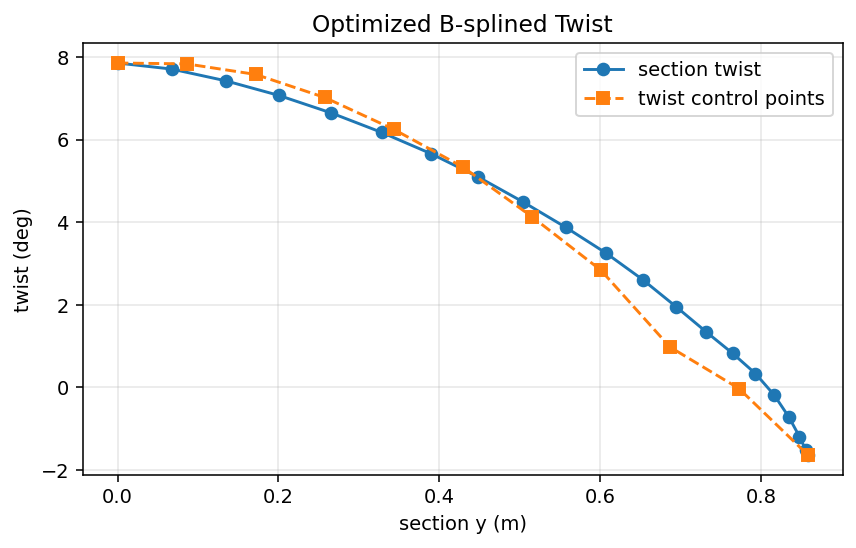

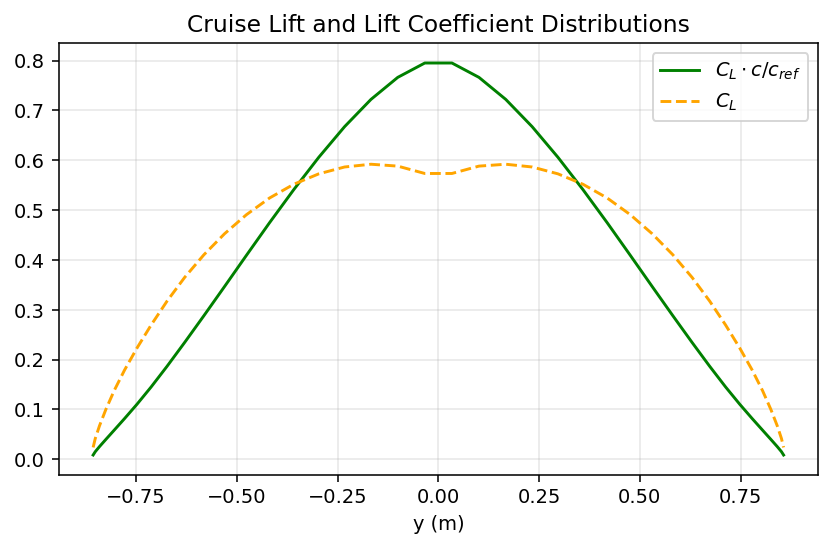

drag [N]: 0.6806796282586283
CL: 0.49999999999547323
root bending moment [N*m]: 4.999999999671175
root bending moment target [N*m]: 5
span [m]: 0.8581492834294285
section_y: [0.         0.06732962 0.13424412 0.20033097 0.26518271 0.32839951
 0.38959162 0.44838177 0.50440749 0.55732338 0.60680318 0.65254183
 0.69425735 0.73169255 0.76461661 0.79282656 0.81614847 0.83443855
 0.84758404 0.8555039  0.85814928]
twist control point y: [0.         0.08581493 0.17162986 0.25744479 0.34325971 0.42907464
 0.51488957 0.6007045  0.68651943 0.77233436 0.85814928]
twist control points: [ 7.85551815  7.83456741  7.57886662  7.02132909  6.24932297  5.33809296
  4.13579921  2.83908325  0.97844861 -0.0273166  -1.63740335]
section twists: [ 7.85551815  7.70898483  7.42592966  7.0717596   6.64913765  6.17411798
  5.66009634  5.0948538   4.48701279  3.87328711  3.25677377  2.61180972
  1.95296095  1.34321713  0.82182891  0.33555742 -0.18537588 -0.71941892
 -1.19276395 -1.52028536 -1.63740335]
twist diffs: 

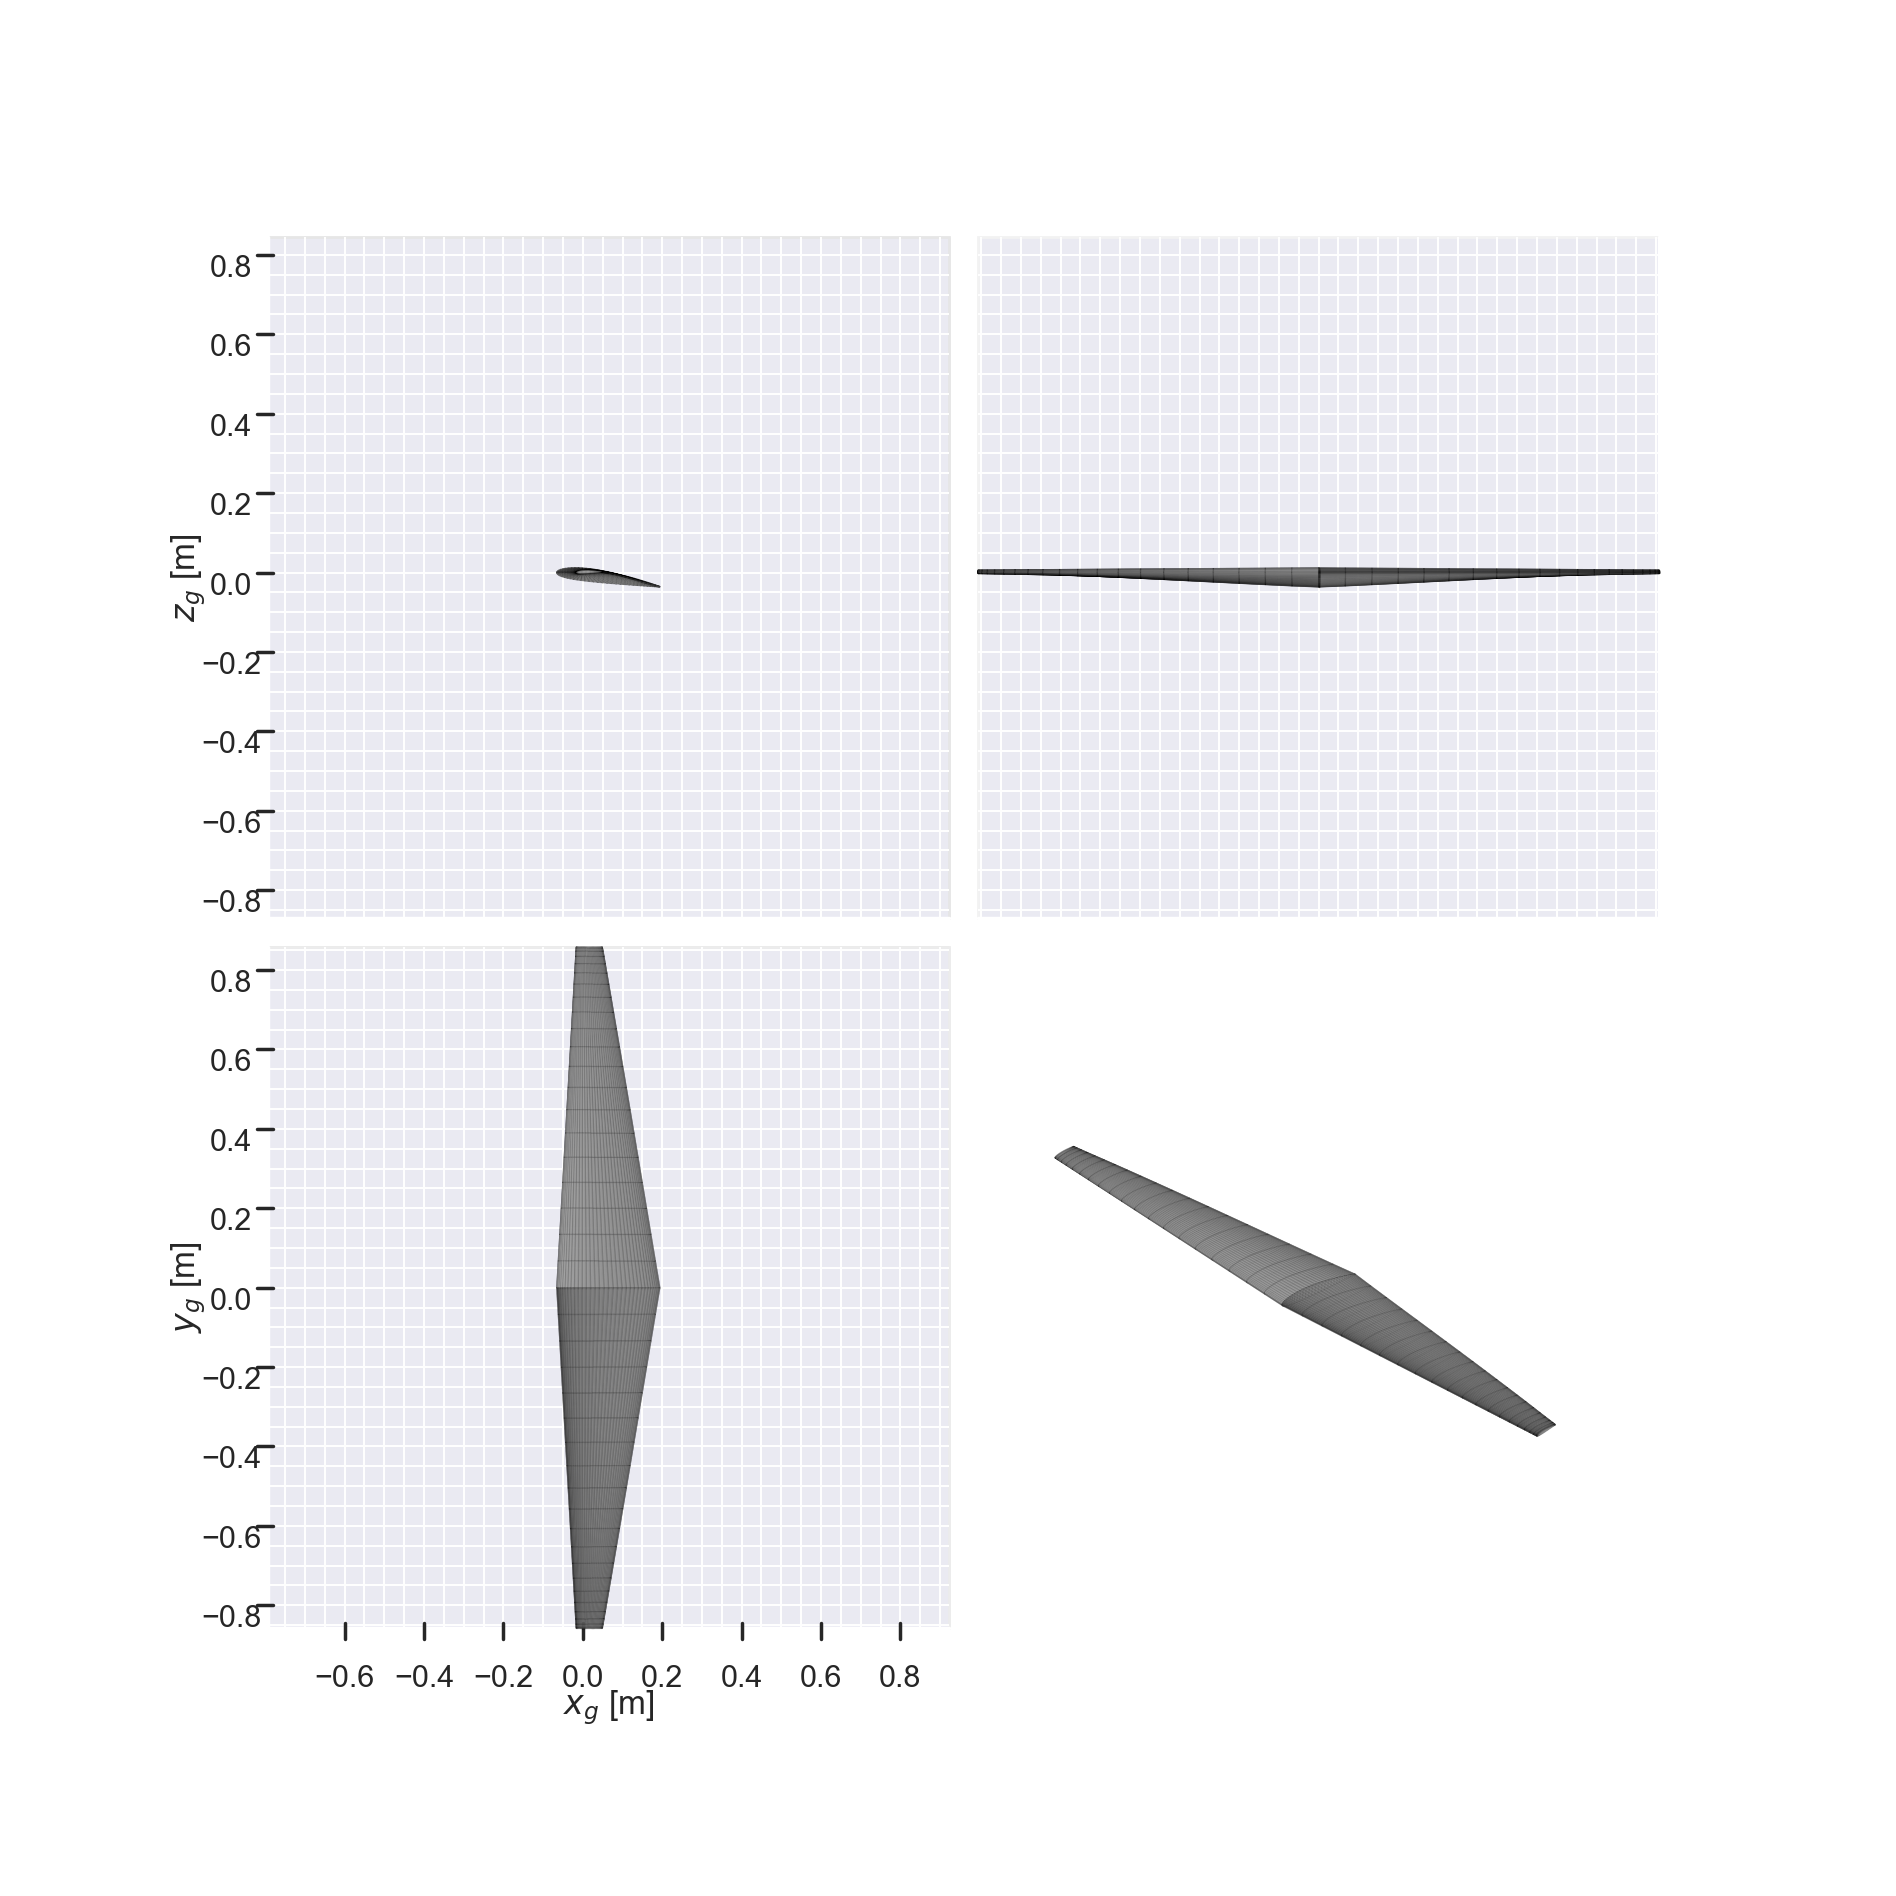

array([[<Axes3D: zlabel='$z_g$ [m]'>, <Axes3D: >],
       [<Axes3D: xlabel='$x_g$ [m]', ylabel='$y_g$ [m]'>, <Axes3D: >]],
      dtype=object)

In [2]:
# Bending moment constrained twist optimization using VLM

opti = asb.Opti()

N = 21
n_twist_cps = 11

# Fixed design targets.
S_ref_target = 0.2808812685
CL_target = 0.5
root_BM_target = 5  # N*m
#wingspan = 0.92  # This is the modeled semispan because the wing is symmetric.
wingspan = opti.variable(init_guess=0.92, lower_bound=0)
taper_ratio = 0.25
velocity = 20
alpha = 0

# These become symbolic when wingspan is an Opti variable.
section_y = np.sinspace(0, wingspan, N, reverse_spacing=True)

chord_root = opti.variable(init_guess=0.25, lower_bound=0)
chord_tip = taper_ratio * chord_root
chords = chord_root + (chord_tip - chord_root) * section_y / wingspan

# Optimize smooth control points, then evaluate twist at every wing section.
twist_cp_y = np.linspace(section_y[0], section_y[-1], n_twist_cps)
twist_cps = opti.variable(
    init_guess=np.zeros(n_twist_cps),
    lower_bound=-30,
    upper_bound=30,
)
twists = asb.bspline(section_y, twist_cps, degree=3)

airplane = asb.Airplane(
    name="Airplane",
    xyz_ref=[0, 0, 0],
    wings=[
        asb.Wing(
            name="Wing",
            symmetric=True,
            xsecs=[
                asb.WingXSec(
                    xyz_le=[-0.25 * chords[i], section_y[i], 0],
                    chord=chords[i],
                    twist=twists[i],
                    airfoil=asb.Airfoil("naca2412"),
                )
                for i in range(N)
            ],
        )
    ],
)

vlm = asb.VortexLatticeMethod(
    airplane=airplane,
    op_point=asb.OperatingPoint(
        velocity=velocity,
        alpha=alpha,
    ),
    spanwise_resolution=1,
    chordwise_resolution=1,
    align_trailing_vortices_with_wind=True,
)
vlm_results = vlm.run()

# Extract distributions in the same style as the lifting-line helper.
n_spanwise = N - 1
n_chordwise = 1
n_sections = 2 * n_spanwise

wind_forces = vlm.op_point.convert_axes(
    vlm.forces_geometry[:, 0],
    vlm.forces_geometry[:, 1],
    vlm.forces_geometry[:, 2],
    from_axes="geometry",
    to_axes="wind",
)
array_L = -wind_forces[2]
array_L_reshaped = np.reshape(array_L, (n_sections, n_chordwise))
strip_L = np.sum(array_L_reshaped, axis=1)

strip_y = vlm.collocation_points[::n_chordwise, 1]
sorted_indices = np.concatenate(
    (
        np.arange(2 * n_spanwise - 1, n_spanwise - 1, -1),
        np.arange(n_spanwise),
    )
)
sorted_y = strip_y[sorted_indices]
sorted_L = strip_L[sorted_indices]

widths = vlm.right_vortex_vertices[:, 1][::n_chordwise] - vlm.left_vortex_vertices[:, 1][::n_chordwise]
sorted_widths = np.abs(widths[sorted_indices])

sorted_chords = chord_root + (chord_tip - chord_root) * (np.abs(sorted_y) / wingspan)

q = vlm.op_point.dynamic_pressure()
sectional_L = sorted_L / sorted_widths
cl = sectional_L / (q * sorted_chords)
clc = cl * sorted_chords
clc_cref = clc / airplane.c_ref

# Half-span data for structural calculations. Use one mirrored side, ordered root-to-tip.
y_half = np.array([np.abs(sorted_y[i]) for i in range(n_spanwise - 1, -1, -1)])
L_half = np.array([sectional_L[i] for i in range(n_spanwise - 1, -1, -1)])

# Concatenate data at the root and tip before integrating to equivalent point forces.
y_half = np.concatenate([np.array([0.0]), y_half, np.array([wingspan])], axis=0)
L_half = np.concatenate([np.array([L_half[0]]), L_half, np.array([0.0])], axis=0)

dy_half = np.diff(y_half)
L_avg = 0.5 * (L_half[:-1] + L_half[1:])
L_forces = L_avg * dy_half
y_forces = 0.5 * (y_half[:-1] + y_half[1:])
root_bending_moment = np.sum(L_forces * y_forces)

opti.subject_to([
    airplane.s_ref == S_ref_target,
    vlm_results["CL"] == CL_target,
    root_bending_moment == root_BM_target,
])

opti.minimize(vlm_results["D"])

sol = opti.solve(behavior_on_failure="return_last", max_iter=500)

sol_drag = sol(vlm_results["D"])
sol_CL = sol(vlm_results["CL"])
sol_root_bending_moment = sol(root_bending_moment)
sol_span = sol(wingspan)
sol_section_y = sol(section_y)
sol_twist_cp_y = sol(twist_cp_y)
sol_twist_cps = sol(twist_cps)
sol_twists = sol(twists)
sol_chords = sol(chords)
sol_sorted_y = sol(sorted_y)
sol_cl = sol(cl)
sol_clc_cref = sol(clc_cref)

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sol_section_y, sol_twists, "o-", label="section twist")
plt.plot(sol_twist_cp_y, sol_twist_cps, "s--", label="twist control points")
plt.xlabel("section y (m)")
plt.ylabel("twist (deg)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Optimized B-splined Twist")
plt.show()

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sol_sorted_y, sol_clc_cref, color="green", label=r"$C_L \cdot c/c_{ref}$")
plt.plot(sol_sorted_y, sol_cl, color="orange", linestyle="--", label=r"$C_L$")
plt.xlabel("y (m)")
plt.legend()
plt.title("Cruise Lift and Lift Coefficient Distributions")
plt.grid(True, alpha=0.3)
plt.show()

print("drag [N]:", sol_drag)
print("CL:", sol_CL)
print("root bending moment [N*m]:", sol_root_bending_moment)
print("root bending moment target [N*m]:", root_BM_target)
print("span [m]:", sol_span)
print("section_y:", sol_section_y)
print("twist control point y:", sol_twist_cp_y)
print("twist control points:", sol_twist_cps)
print("section twists:", sol_twists)
print("twist diffs:", np.diff(sol_twists))
print("chords:", sol_chords)
print("sorted_y:", sol_sorted_y)
print("cl:", sol_cl)
print("clc_cref:", sol_clc_cref)


vlm_sol_drag = sol_drag
vlm_sol_CL = sol_CL
vlm_sol_root_bending_moment = sol_root_bending_moment
vlm_sol_span = sol_span
vlm_sol_section_y = sol_section_y
vlm_sol_twist_cp_y = sol_twist_cp_y
vlm_sol_twist_cps = sol_twist_cps
vlm_sol_twists = sol_twists
vlm_sol_chords = sol_chords
vlm_sol_sorted_y = sol_sorted_y
vlm_sol_cl = sol_cl
vlm_sol_clc_cref = sol_clc_cref

sol(airplane).draw_three_view()

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:       39
Number of nonzeros in inequality constraint Jacobian.:       24
Number of nonzeros in Lagrangian Hessian.............:       91

Total number of variables............................:       13
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        3
Total number of inequality constraints...............:       24
        inequality constraints with only lower bounds:       13
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       11

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  7.7813552e-01 1.93e+00 2.91e-03   0.0 0.00e+00    -  0.00e+00 0.00e+00 

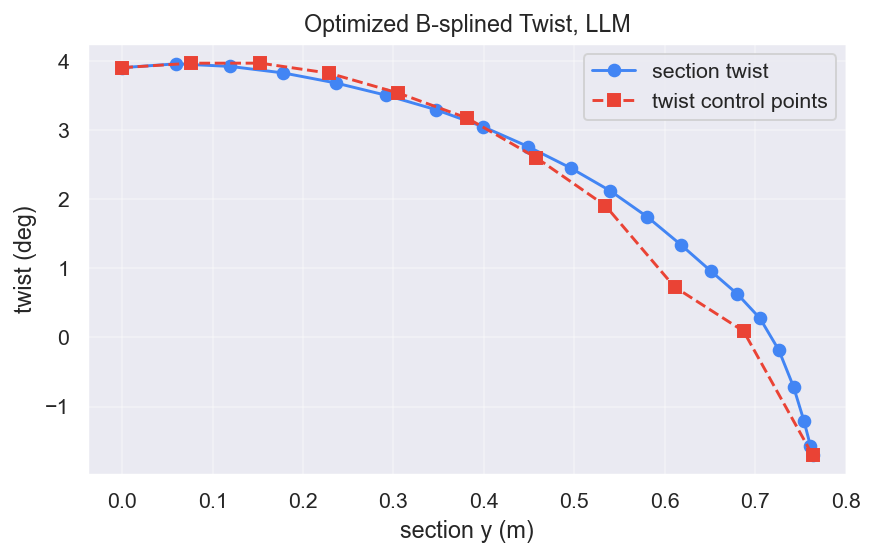

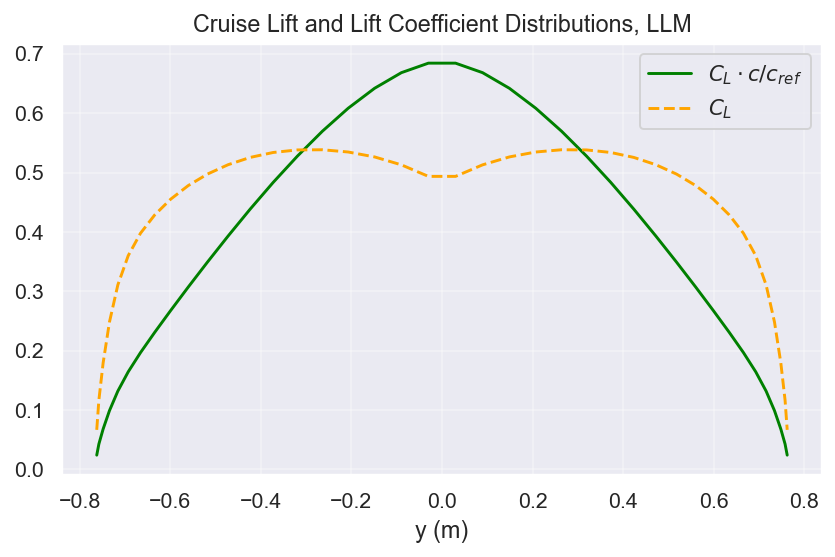

drag [N]: 1.3657214636196287
CD: 0.019846026727987492
CL: 0.4999999999923974
Cm: -0.05887818755801628
x_np [m]: -0.0014770692495372577
root bending moment [N*m]: 4.999999999866919
root bending moment target [N*m]: 5
span [m]: 0.7634380364695322
alpha [deg]: 0.0
taper ratio: 0.25
section_y: [0.         0.05989866 0.11942802 0.17822107 0.23591533 0.29215509
 0.34659362 0.39889528 0.44873762 0.49581334 0.53983221 0.58052284
 0.61763435 0.65093793 0.68022827 0.70532478 0.72607272 0.74234418
 0.75403885 0.76108461 0.76343804]
twist control point y: [0.         0.0763438  0.15268761 0.22903141 0.30537521 0.38171902
 0.45806282 0.53440663 0.61075043 0.68709423 0.76343804]
twist control points: [ 3.90669301  3.97154372  3.97204712  3.82643562  3.53919483  3.17554984
  2.60152857  1.9072531   0.73178463  0.09118401 -1.70393521]
section twists: [ 3.90669301  3.96239931  3.9248232   3.8302497   3.68600682  3.50630713
  3.29991593  3.05278247  2.76455778  2.45470655  2.12195224  1.74762782
  1.344

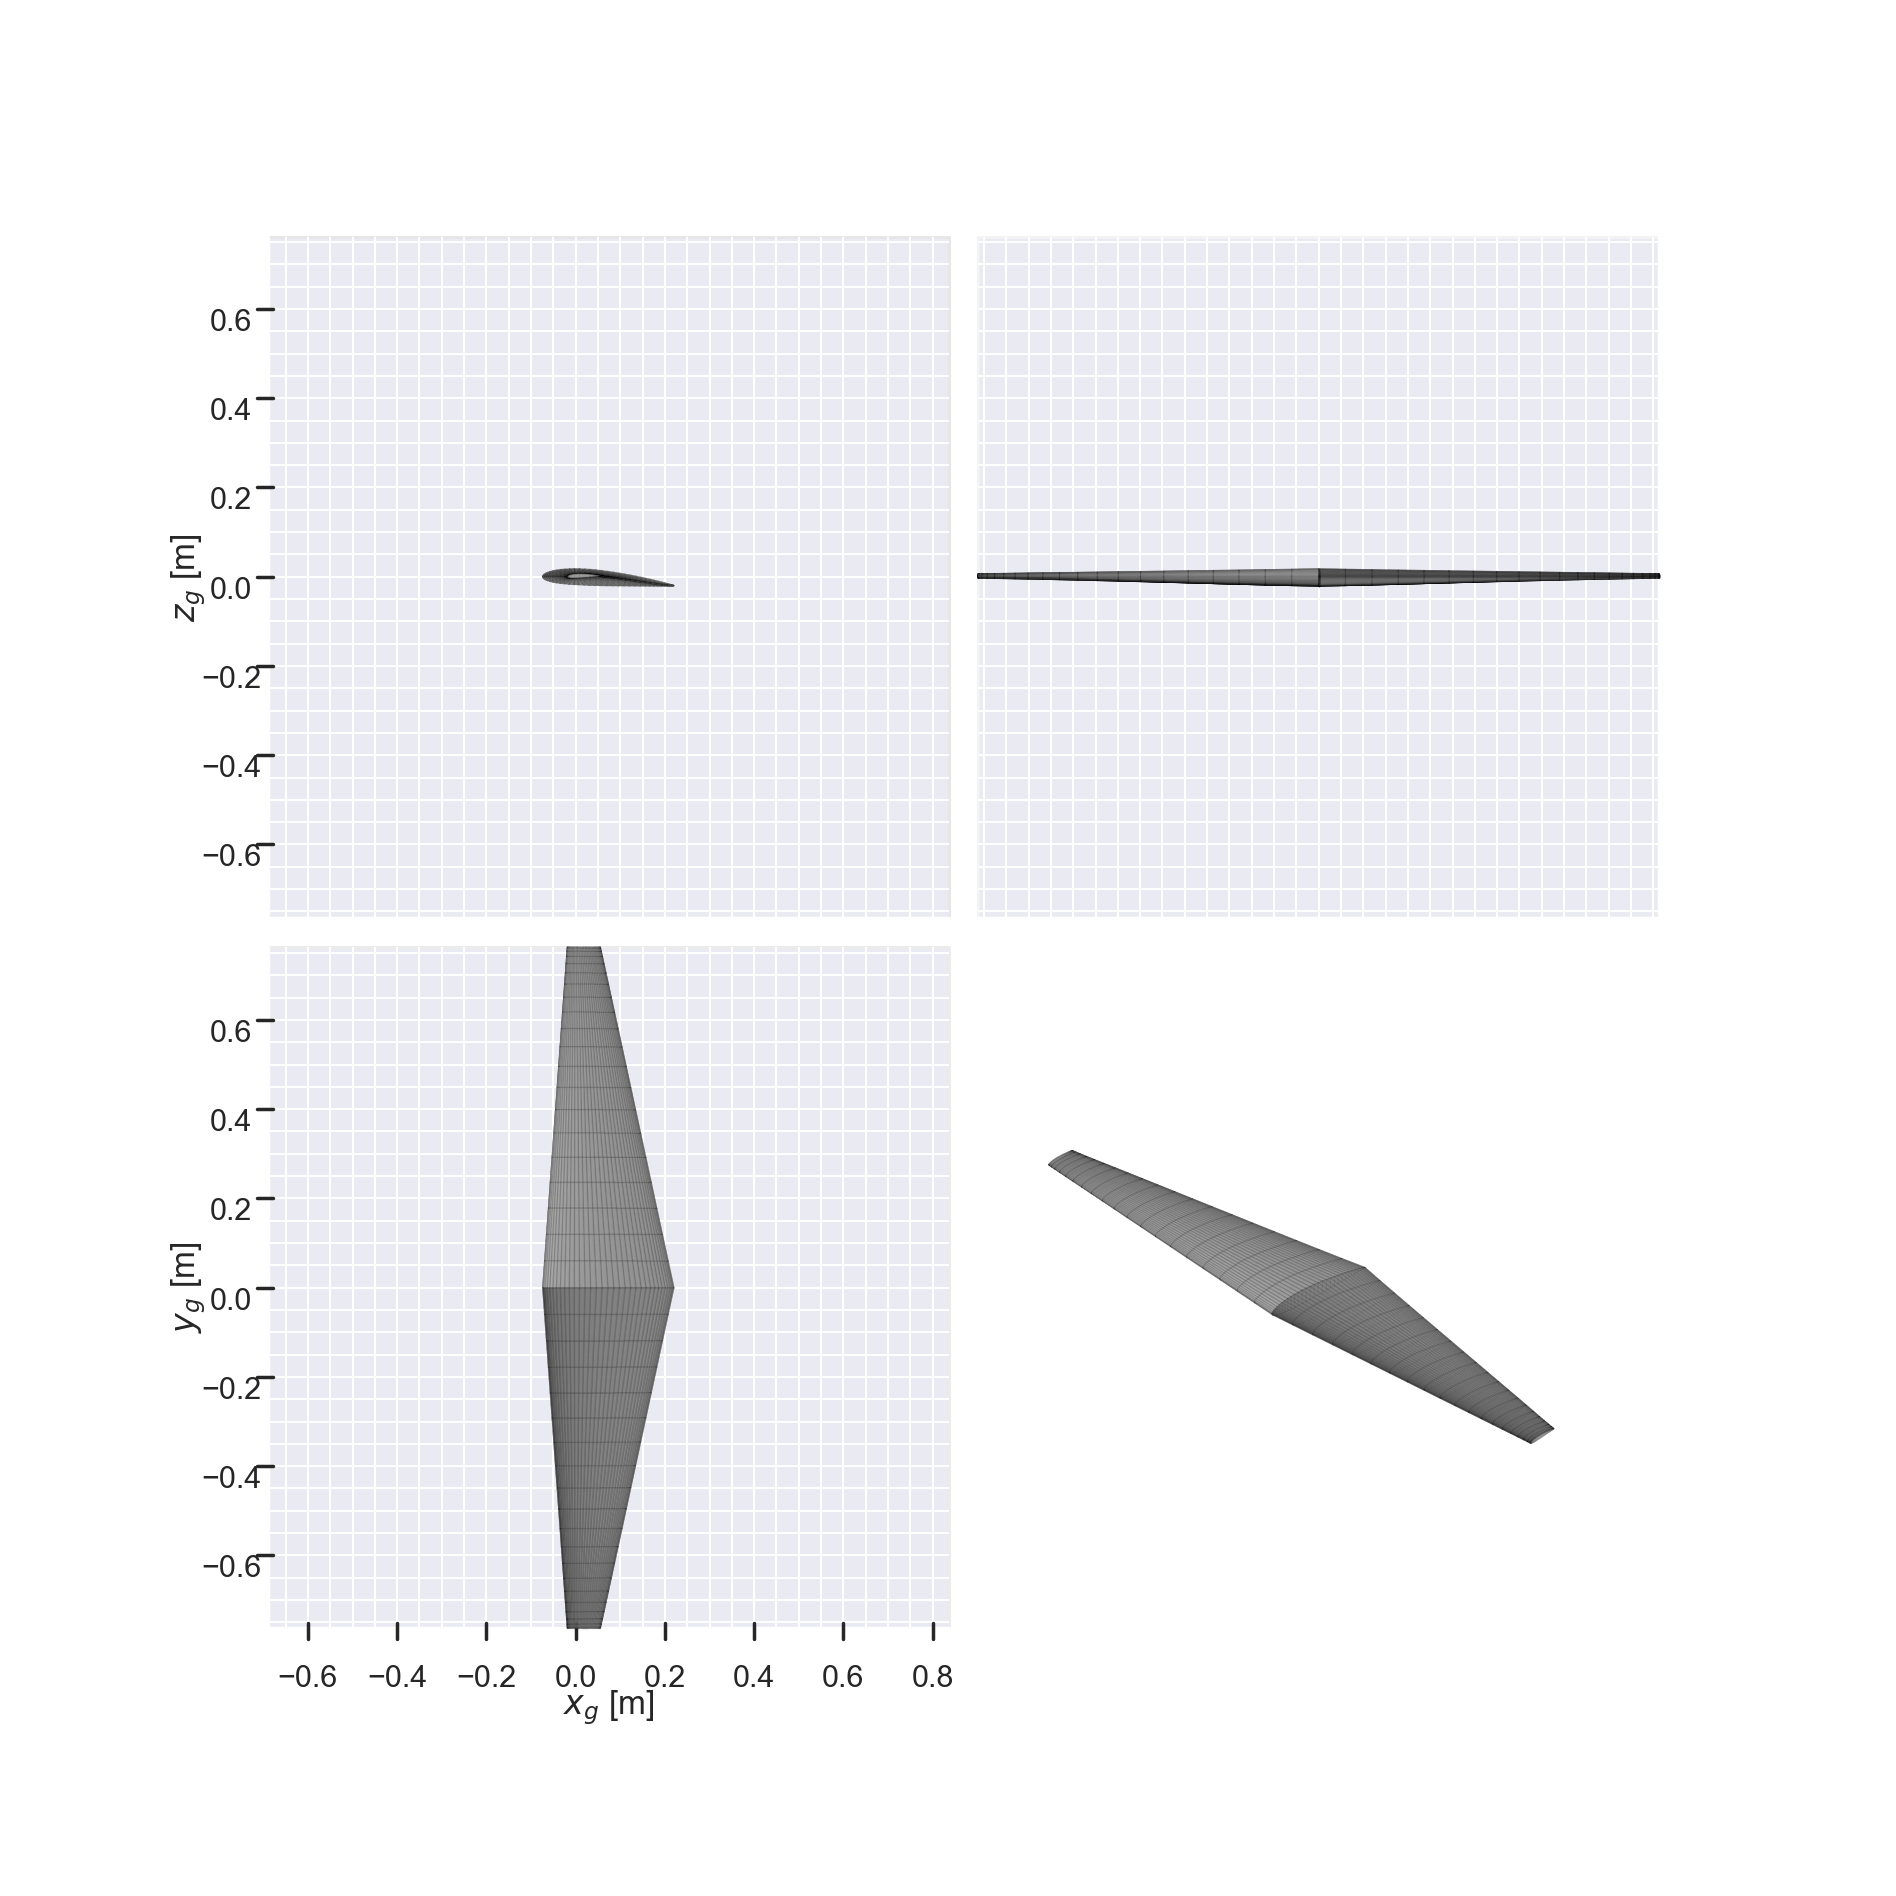

array([[<Axes3D: zlabel='$z_g$ [m]'>, <Axes3D: >],
       [<Axes3D: xlabel='$x_g$ [m]', ylabel='$y_g$ [m]'>, <Axes3D: >]],
      dtype=object)

In [3]:
# Bending moment constrained twist optimization using LLM

opti = asb.Opti()

N = 21
n_twist_cps = 11
llm_spanwise_resolution = 1

# Fixed design targets.
S_ref_target = 0.2808812685
CL_target = 0.5
root_BM_target = 5  # N*m
wingspan = opti.variable(init_guess=0.92, lower_bound=0)  # Modeled semispan; wing is symmetric.
taper_ratio = opti.variable(init_guess=0.25, lower_bound=0, upper_bound=1, freeze=True)
velocity = 20
alpha = opti.variable(init_guess=0, lower_bound=-10, upper_bound=15, freeze=True)

# These become symbolic when wingspan is an Opti variable.
section_y = np.sinspace(0, wingspan, N, reverse_spacing=True)

chord_root = opti.variable(init_guess=0.25, lower_bound=0)
chord_tip = taper_ratio * chord_root
chords = chord_root + (chord_tip - chord_root) * section_y / wingspan

# Optimize smooth control points, then evaluate twist at every wing section.
twist_cp_y = np.linspace(section_y[0], section_y[-1], n_twist_cps)
twist_cps = opti.variable(
    init_guess=np.zeros(n_twist_cps),
    lower_bound=-30,
    upper_bound=30,
)
twists = asb.bspline(section_y, twist_cps, degree=3)

airplane = asb.Airplane(
    name="Airplane",
    xyz_ref=[0, 0, 0],
    wings=[
        asb.Wing(
            name="Wing",
            symmetric=True,
            xsecs=[
                asb.WingXSec(
                    xyz_le=[-0.25 * chords[i], section_y[i], 0],
                    chord=chords[i],
                    twist=twists[i],
                    airfoil=asb.Airfoil("naca2412"),
                )
                for i in range(N)
            ],
        )
    ],
)

llm = asb.LiftingLine(
    airplane=airplane,
    op_point=asb.OperatingPoint(
        velocity=velocity,
        alpha=alpha,
    ),
    spanwise_resolution=llm_spanwise_resolution,
    align_trailing_vortices_with_wind=False,
)
llm_results = llm.run_with_stability_derivatives(
    alpha=True,
    beta=False,
    p=False,
    q=False,
    r=False,
)

# Extract distributions in the same style as the lifting-line helper.
# With one symmetric wing and spanwise_resolution=1, each semispan has N - 1 LLM panels.
n_spanwise = (N - 1) * llm_spanwise_resolution

sorted_indices = np.concatenate(
    (
        np.arange(2 * n_spanwise - 1, n_spanwise - 1, -1),
        np.arange(n_spanwise),
    )
)

strip_y = llm.vortex_centers[:, 1]
sorted_y = strip_y[sorted_indices]

sorted_chords = chord_root + (chord_tip - chord_root) * (np.abs(sorted_y) / wingspan)

vortex_strengths = llm.vortex_strengths
sorted_vortex_strengths = vortex_strengths[sorted_indices]

q = llm.op_point.dynamic_pressure()
sectional_L = (2 * q / velocity) * sorted_vortex_strengths
cl = sectional_L / (q * sorted_chords)
clc = cl * sorted_chords
clc_cref = clc / airplane.c_ref

# Half-span data for structural calculations.
y_half = sorted_y[n_spanwise:]
L_half = sectional_L[n_spanwise:]

# Concatenate data at the root and tip before integrating to equivalent point forces.
y_half = np.concatenate([np.array([0.0]), y_half, np.array([wingspan])], axis=0)
L_half = np.concatenate([np.array([L_half[0]]), L_half, np.array([0.0])], axis=0)

dy_half = np.diff(y_half)
L_avg = 0.5 * (L_half[:-1] + L_half[1:])
L_forces = L_avg * dy_half
y_forces = 0.5 * (y_half[:-1] + y_half[1:])
root_bending_moment = np.sum(L_forces * y_forces)

opti.subject_to([
    airplane.s_ref == S_ref_target,
    llm_results["CL"] == CL_target,
    root_bending_moment == root_BM_target,
])

opti.minimize(llm_results["D"])

sol = opti.solve(behavior_on_failure="return_last", max_iter=500)

sol_drag = sol(llm_results["D"])
sol_CD = sol(llm_results["CD"])
sol_CL = sol(llm_results["CL"])
sol_Cm = sol(llm_results["Cm"])
sol_x_np = sol(llm_results["x_np"])
sol_root_bending_moment = sol(root_bending_moment)
sol_span = sol(wingspan)
sol_alpha = sol(alpha)
sol_taper_ratio = sol(taper_ratio)
sol_section_y = sol(section_y)
sol_twist_cp_y = sol(twist_cp_y)
sol_twist_cps = sol(twist_cps)
sol_twists = sol(twists)
sol_chords = sol(chords)
sol_sorted_y = sol(sorted_y)
sol_cl = sol(cl)
sol_clc_cref = sol(clc_cref)

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sol_section_y, sol_twists, "o-", label="section twist")
plt.plot(sol_twist_cp_y, sol_twist_cps, "s--", label="twist control points")
plt.xlabel("section y (m)")
plt.ylabel("twist (deg)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Optimized B-splined Twist, LLM")
plt.show()

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sol_sorted_y, sol_clc_cref, color="green", label=r"$C_L \cdot c/c_{ref}$")
plt.plot(sol_sorted_y, sol_cl, color="orange", linestyle="--", label=r"$C_L$")
plt.xlabel("y (m)")
plt.legend()
plt.title("Cruise Lift and Lift Coefficient Distributions, LLM")
plt.grid(True, alpha=0.3)
plt.show()

print("drag [N]:", sol_drag)
print("CD:", sol_CD)
print("CL:", sol_CL)
print("Cm:", sol_Cm)
print("x_np [m]:", sol_x_np)
print("root bending moment [N*m]:", sol_root_bending_moment)
print("root bending moment target [N*m]:", root_BM_target)
print("span [m]:", sol_span)
print("alpha [deg]:", sol_alpha)
print("taper ratio:", sol_taper_ratio)
print("section_y:", sol_section_y)
print("twist control point y:", sol_twist_cp_y)
print("twist control points:", sol_twist_cps)
print("section twists:", sol_twists)
print("twist diffs:", np.diff(sol_twists))
print("chords:", sol_chords)
print("sorted_y:", sol_sorted_y)
print("cl:", sol_cl)
print("clc_cref:", sol_clc_cref)


llm_sol_drag = sol_drag
llm_sol_CD = sol_CD
llm_sol_CL = sol_CL
llm_sol_Cm = sol_Cm
llm_sol_x_np = sol_x_np
llm_sol_root_bending_moment = sol_root_bending_moment
llm_sol_span = sol_span
llm_sol_alpha = sol_alpha
llm_sol_taper_ratio = sol_taper_ratio
llm_sol_section_y = sol_section_y
llm_sol_twist_cp_y = sol_twist_cp_y
llm_sol_twist_cps = sol_twist_cps
llm_sol_twists = sol_twists
llm_sol_chords = sol_chords
llm_sol_sorted_y = sol_sorted_y
llm_sol_cl = sol_cl
llm_sol_clc_cref = sol_clc_cref

sol(airplane).draw_three_view()

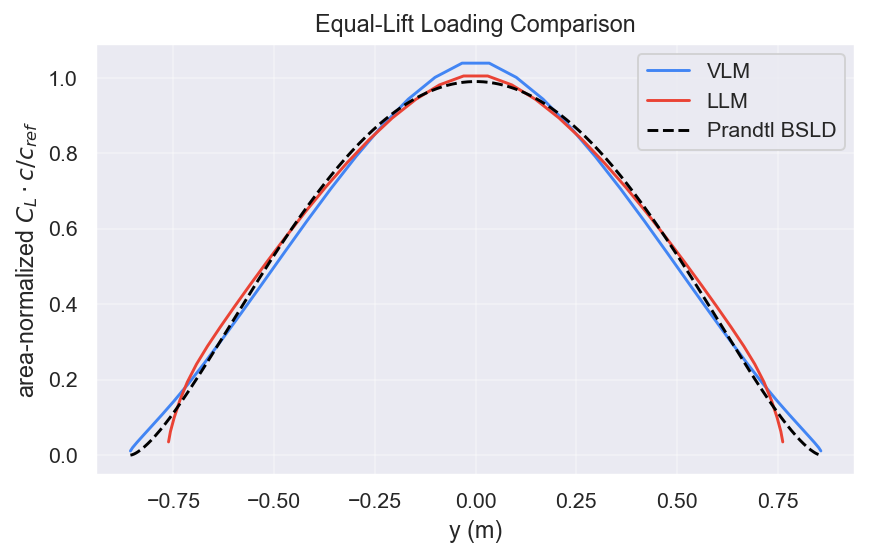

In [4]:
# Compare VLM/LLM loading to BSLD

def _area_normalized_curve(y, loading):
    y = np.ravel(y)
    loading = np.ravel(loading)
    order = np.argsort(y)
    y = y[order]
    loading = loading[order]
    area = np.sum(0.5 * (loading[:-1] + loading[1:]) * np.diff(y))
    return y, loading / area

vlm_y_plot, vlm_clc_plot = _area_normalized_curve(vlm_sol_sorted_y, vlm_sol_clc_cref)
llm_y_plot, llm_clc_plot = _area_normalized_curve(llm_sol_sorted_y, llm_sol_clc_cref)

bsld_semispan = np.max(np.abs(np.concatenate([vlm_y_plot, llm_y_plot])))
bsld_y = np.linspace(-bsld_semispan, bsld_semispan, 400)
bsld_clc = (1 - (bsld_y / bsld_semispan) ** 2) ** 1.5
bsld_y_plot, bsld_clc_plot = _area_normalized_curve(bsld_y, bsld_clc)

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(vlm_y_plot, vlm_clc_plot, label="VLM")
plt.plot(llm_y_plot, llm_clc_plot, label="LLM")
plt.plot(bsld_y_plot, bsld_clc_plot, "k--", label="Prandtl BSLD")
plt.xlabel("y (m)")
plt.ylabel(r"area-normalized $C_L \cdot c/c_{ref}$")
plt.title("Equal-Lift Loading Comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:       57
Number of nonzeros in inequality constraint Jacobian.:       49
Number of nonzeros in Lagrangian Hessian.............:      190

Total number of variables............................:       19
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        3
Total number of inequality constraints...............:       43
        inequality constraints with only lower bounds:       19
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       24

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  6.0543582e-01 3.24e+00 7.24e-02   0.0 0.00e+00    -  0.00e+00 0.00e+00 

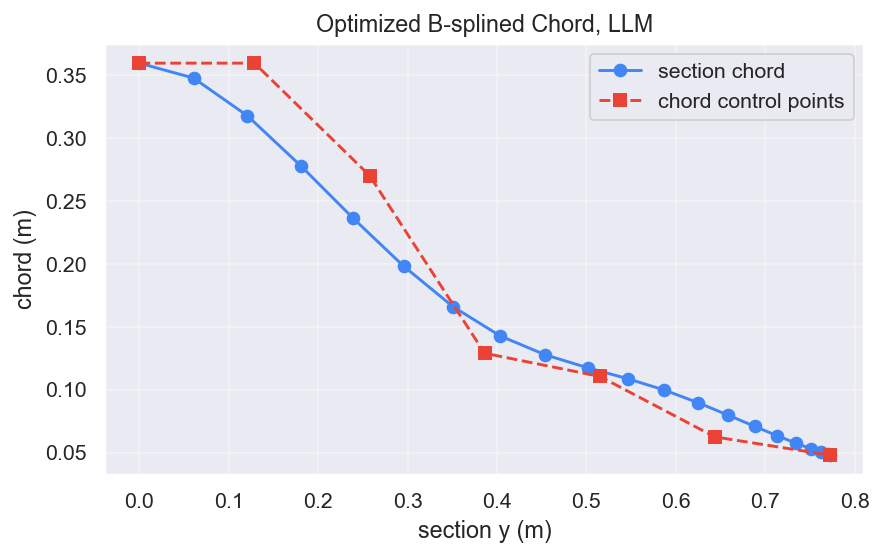

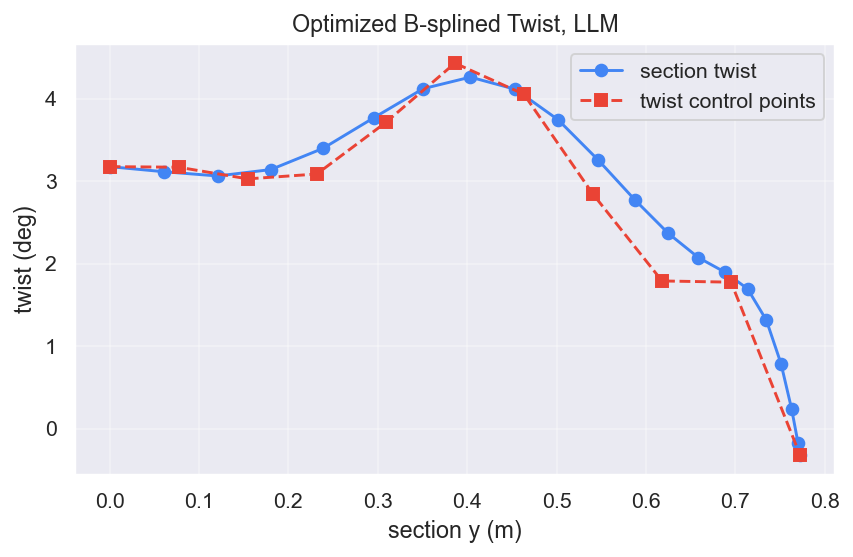

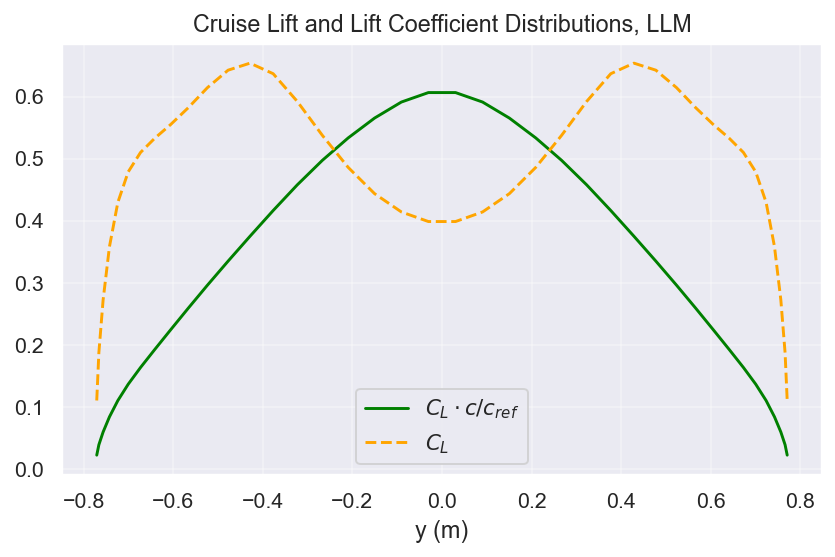

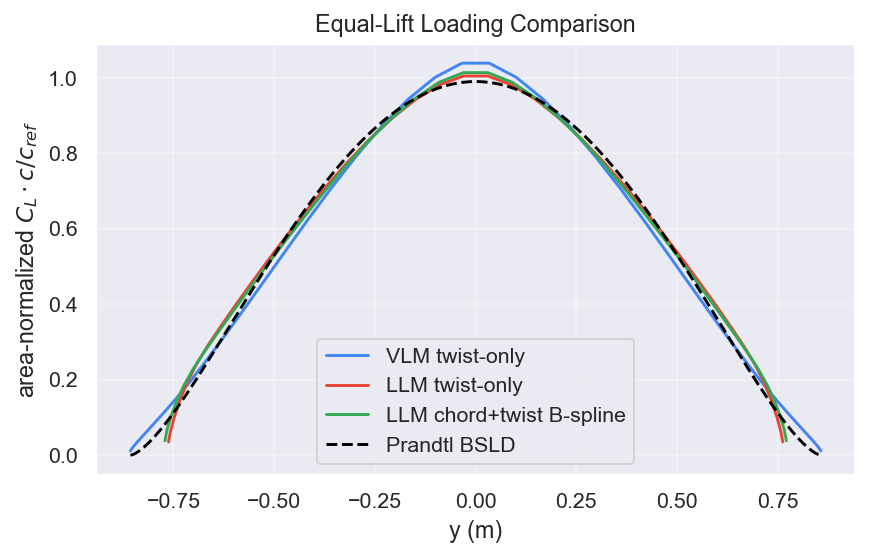

drag [N]: 1.3559115522351037
CD: 0.019703473675453904
CL: 0.4999999999434081
Cm: -0.054373142497490944
x_np [m]: -0.0014770692495372577
root bending moment [N*m]: 4.999999999330534
root bending moment target [N*m]: 5
span [m]: 0.77226581197587
section_y: [0.         0.06059128 0.12080899 0.18028187 0.23864326 0.29553333
 0.35060134 0.40350778 0.45392646 0.50154652 0.54607439 0.58723553
 0.62477617 0.65846485 0.68809388 0.71348058 0.73446843 0.75092805
 0.76275794 0.76988517 0.77226581]
chord control point y: [0.         0.12871097 0.25742194 0.38613291 0.51484387 0.64355484
 0.77226581]
chord control points: [0.35980794 0.35980794 0.27038001 0.12905982 0.11064828 0.06253462
 0.04799183]
section chords: [0.35980794 0.34794103 0.31794705 0.2782756  0.23675495 0.19831538
 0.16618926 0.14283338 0.12780291 0.11747236 0.10881662 0.09975803
 0.08974179 0.07984141 0.07090688 0.06340051 0.05748845 0.05313734
 0.05020739 0.0485341  0.04799183]
twist control point y: [0.         0.07722658 0.1544

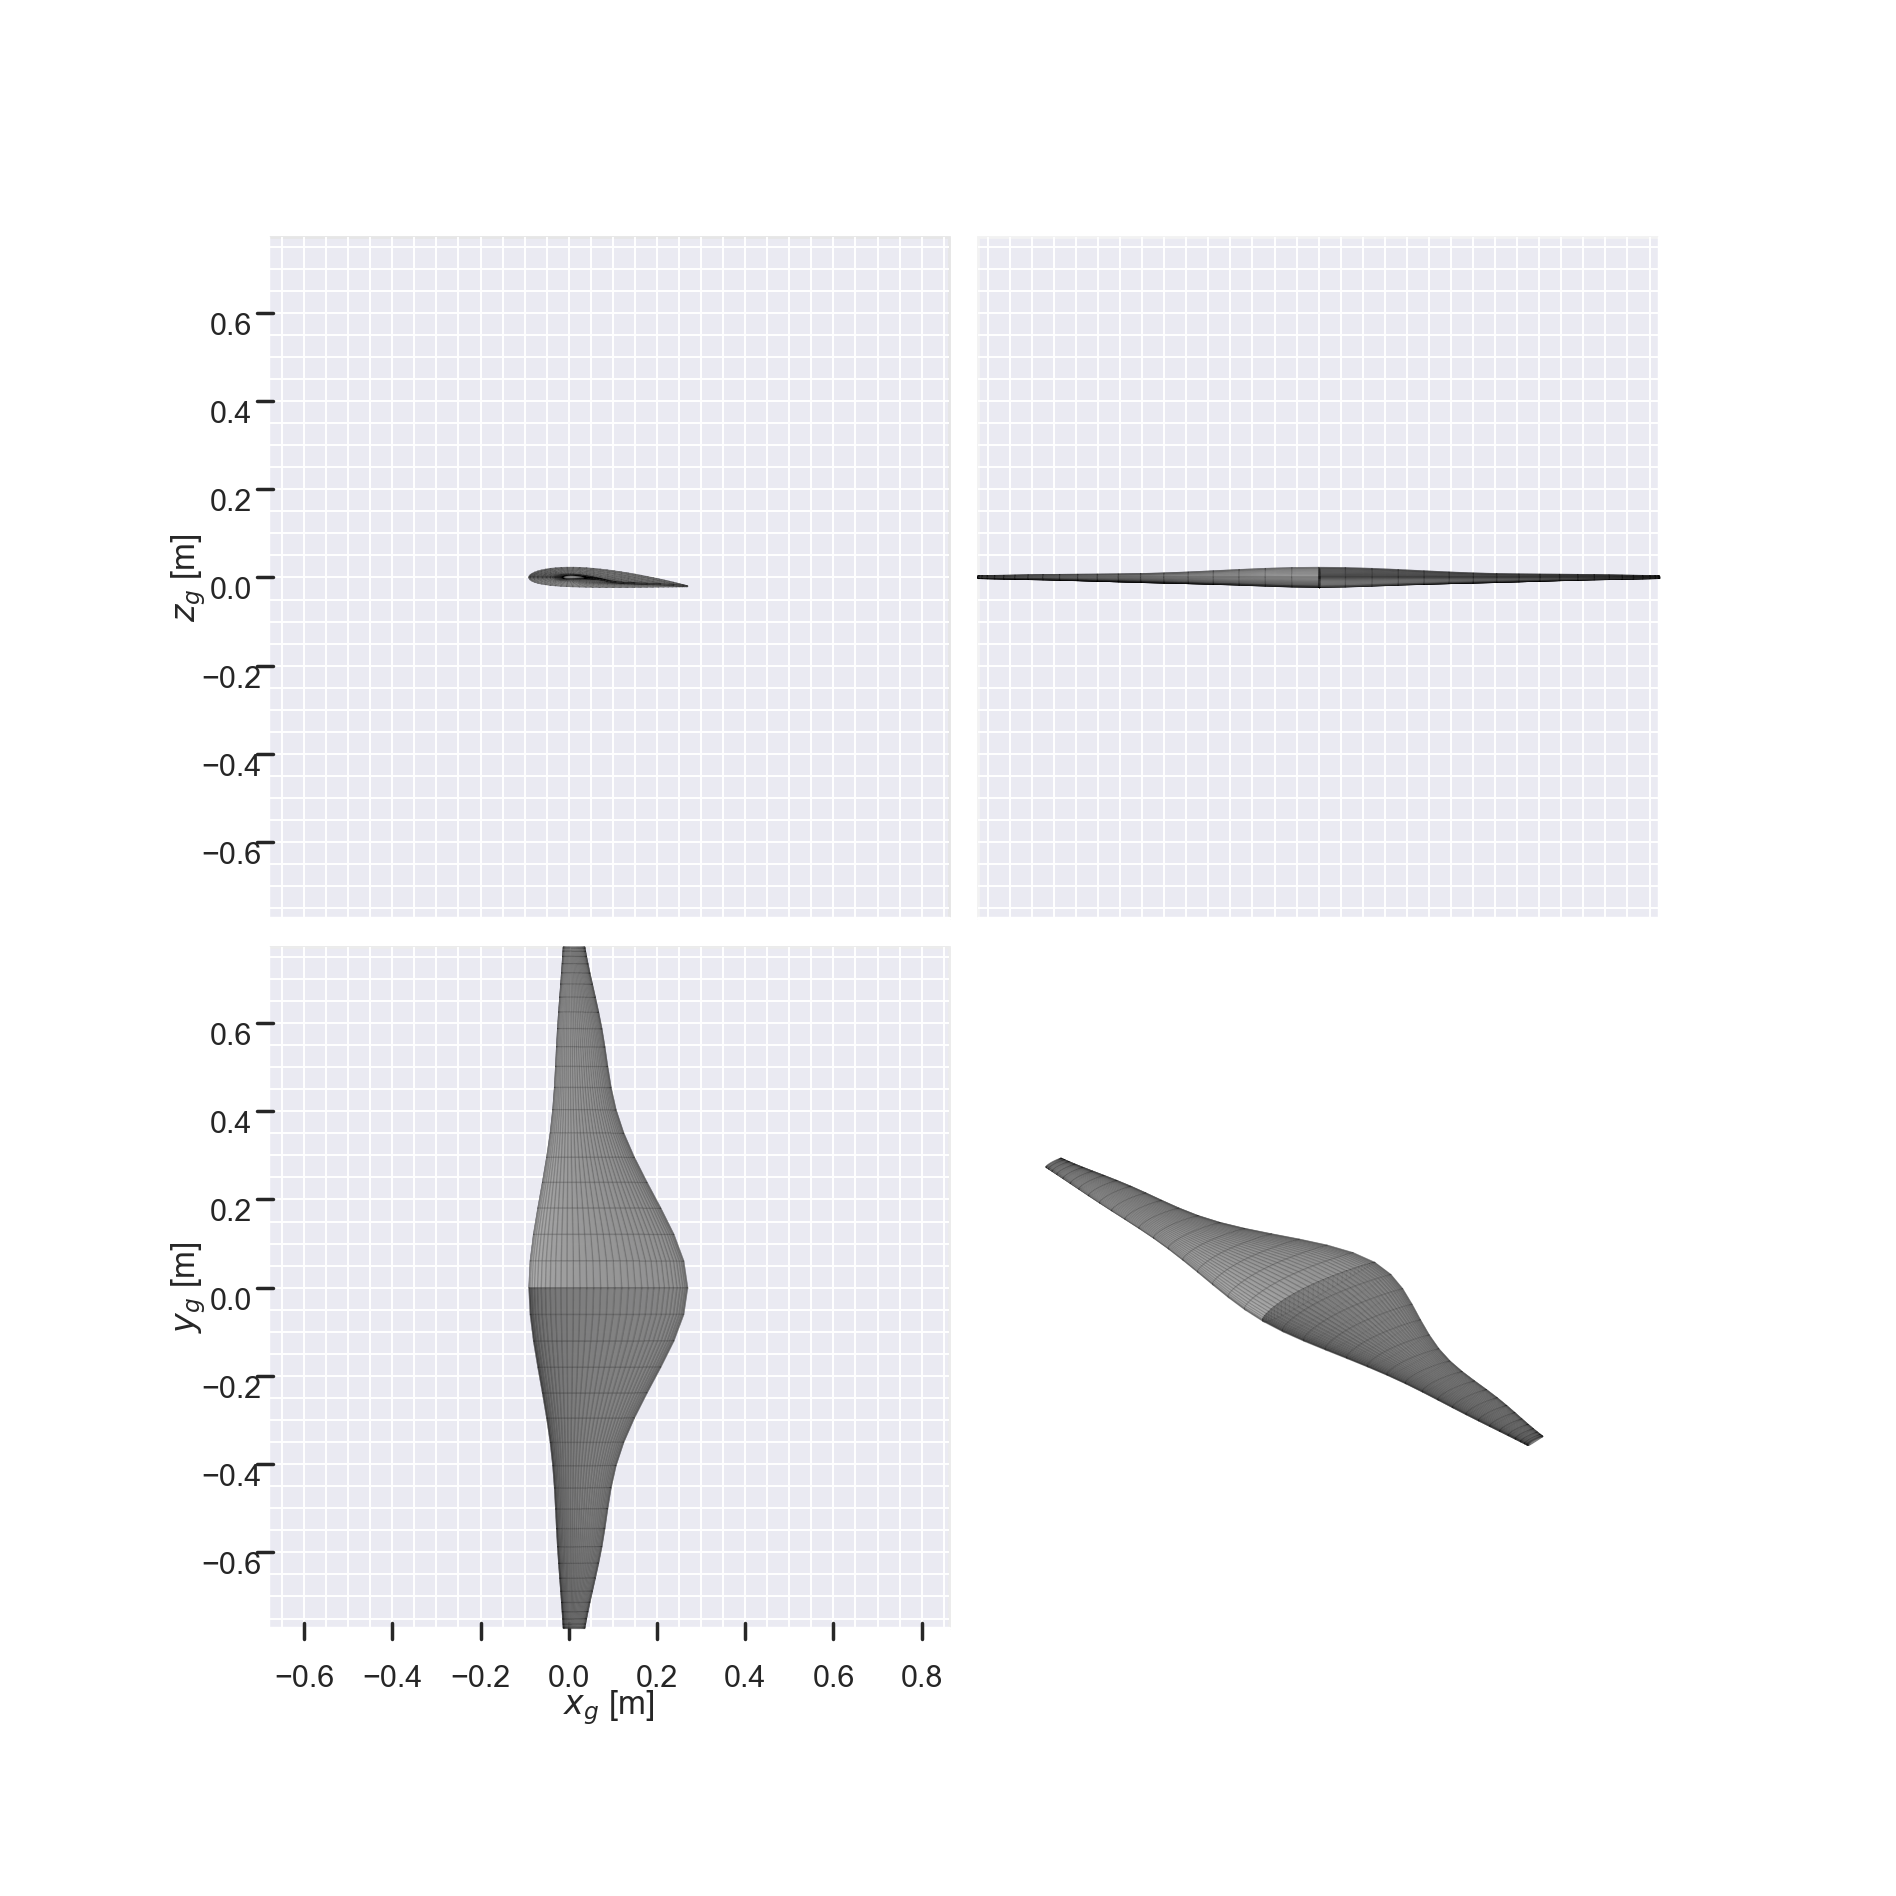

array([[<Axes3D: zlabel='$z_g$ [m]'>, <Axes3D: >],
       [<Axes3D: xlabel='$x_g$ [m]', ylabel='$y_g$ [m]'>, <Axes3D: >]],
      dtype=object)

In [5]:
# Optimize LLM with B-splined chord and twist.

opti = asb.Opti()

N = 21
n_chord_cps = 7
n_twist_cps = 11
llm_spanwise_resolution = 1

S_ref_target = 0.2808812685
CL_target = 0.5
root_BM_target = 5  # N*m
wingspan = opti.variable(init_guess=0.7, lower_bound=0)
taper_ratio = 0.25
velocity = 20
alpha = 0

section_y = np.sinspace(0, wingspan, N, reverse_spacing=True)
section_eta = section_y / wingspan

def open_uniform_unit_knots(n_control_points, degree):
    n_internal_knots = n_control_points - degree - 1
    if n_internal_knots > 0:
        internal_knots = np.linspace(0, 1, n_internal_knots + 2)[1:-1]
    else:
        internal_knots = np.array([])
    return np.concatenate([
        np.zeros(degree + 1),
        internal_knots,
        np.ones(degree + 1),
    ])

chord_degree = 3
chord_knots = open_uniform_unit_knots(n_chord_cps, chord_degree)
chord_cp_y = np.linspace(section_y[0], section_y[-1], n_chord_cps)
initial_chord_cps = np.linspace(0.25, 0.25 * taper_ratio, n_chord_cps)
chord_cps = opti.variable(
    init_guess=initial_chord_cps,
    lower_bound=0.02,
    upper_bound=0.8,
)
chords = asb.bspline(section_eta, chord_cps, degree=chord_degree, knots=chord_knots)

# Keep the optimized chord control polygon generally tapered. Remove this if you want non-monotonic planforms.
opti.subject_to(chord_cps[1:] <= chord_cps[:-1])

twist_degree = 3
twist_knots = open_uniform_unit_knots(n_twist_cps, twist_degree)
twist_cp_y = np.linspace(section_y[0], section_y[-1], n_twist_cps)
twist_cps = opti.variable(
    init_guess=np.zeros(n_twist_cps),
    lower_bound=-30,
    upper_bound=30,
)
twists = asb.bspline(section_eta, twist_cps, degree=twist_degree, knots=twist_knots)

airplane = asb.Airplane(
    name="Airplane",
    xyz_ref=[0, 0, 0],
    wings=[
        asb.Wing(
            name="Wing",
            symmetric=True,
            xsecs=[
                asb.WingXSec(
                    xyz_le=[-0.25 * chords[i], section_y[i], 0],
                    chord=chords[i],
                    twist=twists[i],
                    airfoil=asb.Airfoil("naca2412"),
                )
                for i in range(N)
            ],
        )
    ],
)

llm = asb.LiftingLine(
    airplane=airplane,
    op_point=asb.OperatingPoint(
        velocity=velocity,
        alpha=alpha,
    ),
    spanwise_resolution=llm_spanwise_resolution,
    align_trailing_vortices_with_wind=False,
)
llm_results = llm.run()

n_spanwise = (N - 1) * llm_spanwise_resolution
sorted_indices = np.concatenate(
    (
        np.arange(2 * n_spanwise - 1, n_spanwise - 1, -1),
        np.arange(n_spanwise),
    )
)

strip_y = llm.vortex_centers[:, 1]
sorted_y = strip_y[sorted_indices]
sorted_eta = np.abs(sorted_y) / wingspan
sorted_chords = asb.bspline(sorted_eta, chord_cps, degree=chord_degree, knots=chord_knots)

vortex_strengths = llm.vortex_strengths
sorted_vortex_strengths = vortex_strengths[sorted_indices]

q = llm.op_point.dynamic_pressure()
sectional_L = (2 * q / velocity) * sorted_vortex_strengths
cl = sectional_L / (q * sorted_chords)
clc = cl * sorted_chords
clc_cref = clc / airplane.c_ref

y_half = sorted_y[n_spanwise:]
L_half = sectional_L[n_spanwise:]

y_half = np.concatenate([np.array([0.0]), y_half, np.array([wingspan])], axis=0)
L_half = np.concatenate([np.array([L_half[0]]), L_half, np.array([0.0])], axis=0)

dy_half = np.diff(y_half)
L_avg = 0.5 * (L_half[:-1] + L_half[1:])
L_forces = L_avg * dy_half
y_forces = 0.5 * (y_half[:-1] + y_half[1:])
root_bending_moment = np.sum(L_forces * y_forces)

opti.subject_to([
    airplane.s_ref == S_ref_target,
    llm_results["CL"] == CL_target,
    root_bending_moment == root_BM_target,
])

opti.minimize(llm_results["D"])

sol = opti.solve(behavior_on_failure="return_last", max_iter=500)

sol_drag = sol(llm_results["D"])
sol_CD = sol(llm_results["CD"])
sol_CL = sol(llm_results["CL"])
sol_Cm = sol(llm_results["Cm"])
sol_root_bending_moment = sol(root_bending_moment)
sol_span = sol(wingspan)
sol_section_y = sol(section_y)
sol_chord_cp_y = sol(chord_cp_y)
sol_chord_cps = sol(chord_cps)
sol_chords = sol(chords)
sol_twist_cp_y = sol(twist_cp_y)
sol_twist_cps = sol(twist_cps)
sol_twists = sol(twists)
sol_sorted_y = sol(sorted_y)
sol_cl = sol(cl)
sol_clc_cref = sol(clc_cref)

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sol_section_y, sol_chords, "o-", label="section chord")
plt.plot(sol_chord_cp_y, sol_chord_cps, "s--", label="chord control points")
plt.xlabel("section y (m)")
plt.ylabel("chord (m)")
plt.title("Optimized B-splined Chord, LLM")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sol_section_y, sol_twists, "o-", label="section twist")
plt.plot(sol_twist_cp_y, sol_twist_cps, "s--", label="twist control points")
plt.xlabel("section y (m)")
plt.ylabel("twist (deg)")
plt.title("Optimized B-splined Twist, LLM")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sol_sorted_y, sol_clc_cref, color="green", label=r"$C_L \cdot c/c_{ref}$")
plt.plot(sol_sorted_y, sol_cl, color="orange", linestyle="--", label=r"$C_L$")
plt.xlabel("y (m)")
plt.legend()
plt.title("Cruise Lift and Lift Coefficient Distributions, LLM")
plt.grid(True, alpha=0.3)
plt.show()

llm_chord_y_plot, llm_chord_clc_plot = _area_normalized_curve(sol_sorted_y, sol_clc_cref)
comparison_semispan = np.max(np.abs(np.concatenate([vlm_y_plot, llm_y_plot, llm_chord_y_plot])))
comparison_y = np.linspace(-comparison_semispan, comparison_semispan, 400)
comparison_bell = (1 - (comparison_y / comparison_semispan) ** 2) ** 1.5
comparison_y_plot, comparison_bell_plot = _area_normalized_curve(comparison_y, comparison_bell)

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(vlm_y_plot, vlm_clc_plot, label="VLM twist-only")
plt.plot(llm_y_plot, llm_clc_plot, label="LLM twist-only")
plt.plot(llm_chord_y_plot, llm_chord_clc_plot, label="LLM chord+twist B-spline")
plt.plot(comparison_y_plot, comparison_bell_plot, "k--", label="Prandtl BSLD")
plt.xlabel("y (m)")
plt.ylabel(r"area-normalized $C_L \cdot c/c_{ref}$")
plt.title("Equal-Lift Loading Comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("drag [N]:", sol_drag)
print("CD:", sol_CD)
print("CL:", sol_CL)
print("Cm:", sol_Cm)
print("x_np [m]:", sol_x_np)
print("root bending moment [N*m]:", sol_root_bending_moment)
print("root bending moment target [N*m]:", root_BM_target)
print("span [m]:", sol_span)
print("section_y:", sol_section_y)
print("chord control point y:", sol_chord_cp_y)
print("chord control points:", sol_chord_cps)
print("section chords:", sol_chords)
print("twist control point y:", sol_twist_cp_y)
print("twist control points:", sol_twist_cps)
print("section twists:", sol_twists)
print("sorted_y:", sol_sorted_y)
print("cl:", sol_cl)
print("clc_cref:", sol_clc_cref)

sol(airplane).draw_three_view()

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:       57
Number of nonzeros in inequality constraint Jacobian.:       37
Number of nonzeros in Lagrangian Hessian.............:      190

Total number of variables............................:       19
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        3
Total number of inequality constraints...............:       37
        inequality constraints with only lower bounds:       19
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       18

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  6.0543582e-01 3.24e+00 2.11e-02   0.0 0.00e+00    -  0.00e+00 0.00e+00 

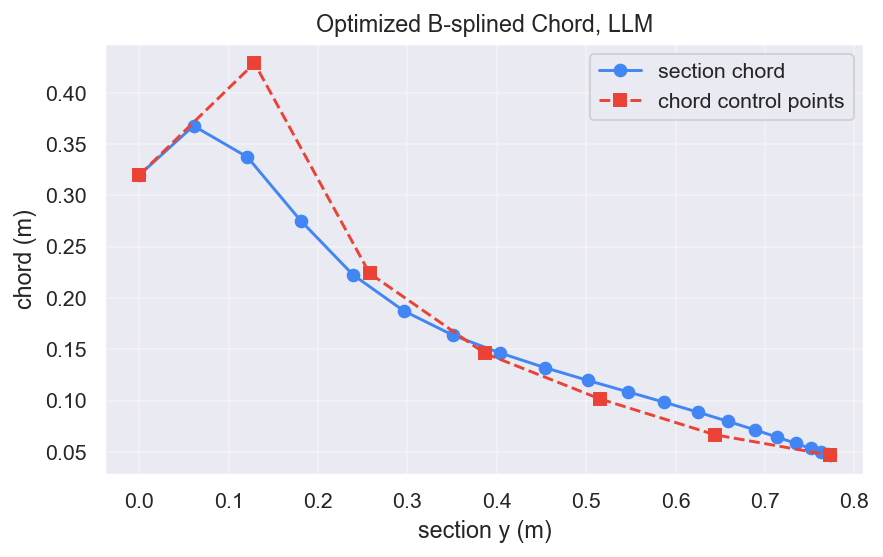

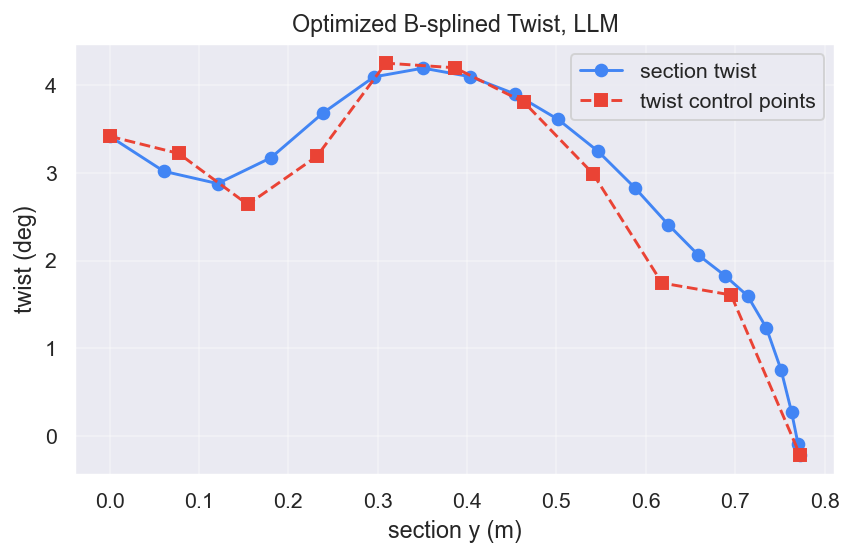

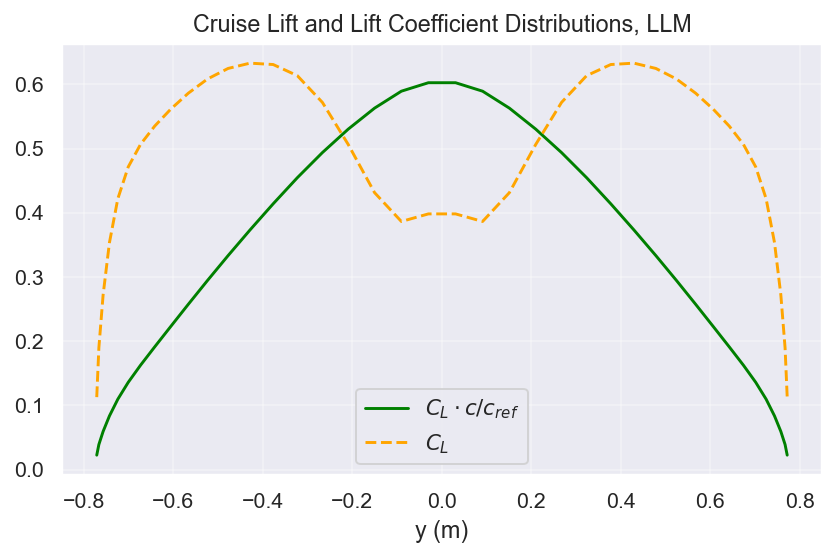

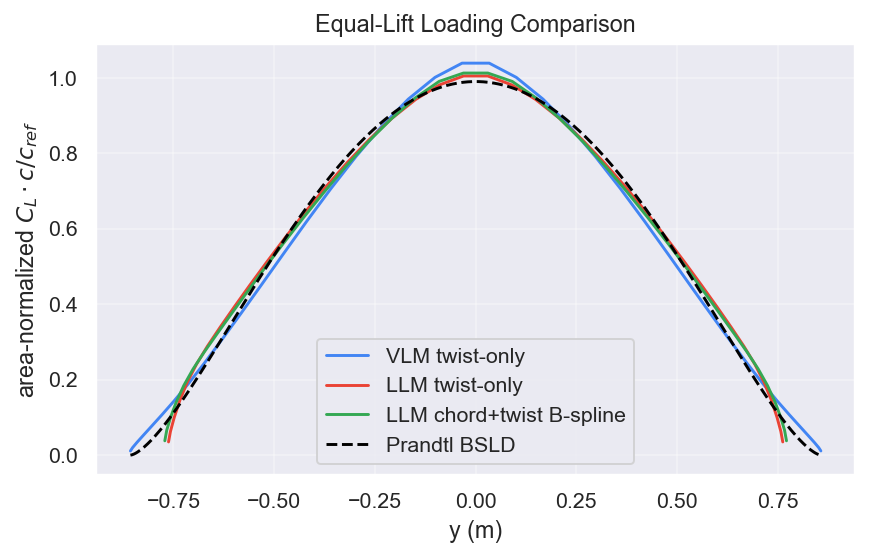

drag [N]: 1.3556651340013746
CD: 0.019699892840721312
CL: 0.5000000000000226
Cm: -0.05400741813533428
x_np [m]: -0.0014770692495372577
root bending moment [N*m]: 5.000000000000577
root bending moment target [N*m]: 5
span [m]: 0.7726684519013776
section_y: [0.         0.06062287 0.12087198 0.18037587 0.23876768 0.29568742
 0.35078414 0.40371816 0.45416312 0.50180802 0.5463591  0.5875417
 0.62510191 0.65880816 0.68845263 0.71385257 0.73485137 0.75131956
 0.76315562 0.77028657 0.77266845]
chord control point y: [0.         0.12877808 0.25755615 0.38633423 0.5151123  0.64389038
 0.77266845]
chord control points: [0.32003388 0.42901917 0.22416674 0.14620936 0.10176675 0.06673437
 0.04684003]
section chords: [0.32003388 0.367893   0.33745072 0.27557212 0.2228765  0.18757676
 0.16382927 0.14641817 0.13207118 0.11971675 0.10865201 0.09839009
 0.08872812 0.07975112 0.07158932 0.06437999 0.05825867 0.05335046
 0.04976204 0.04757488 0.04684003]
twist control point y: [0.         0.07726685 0.1545

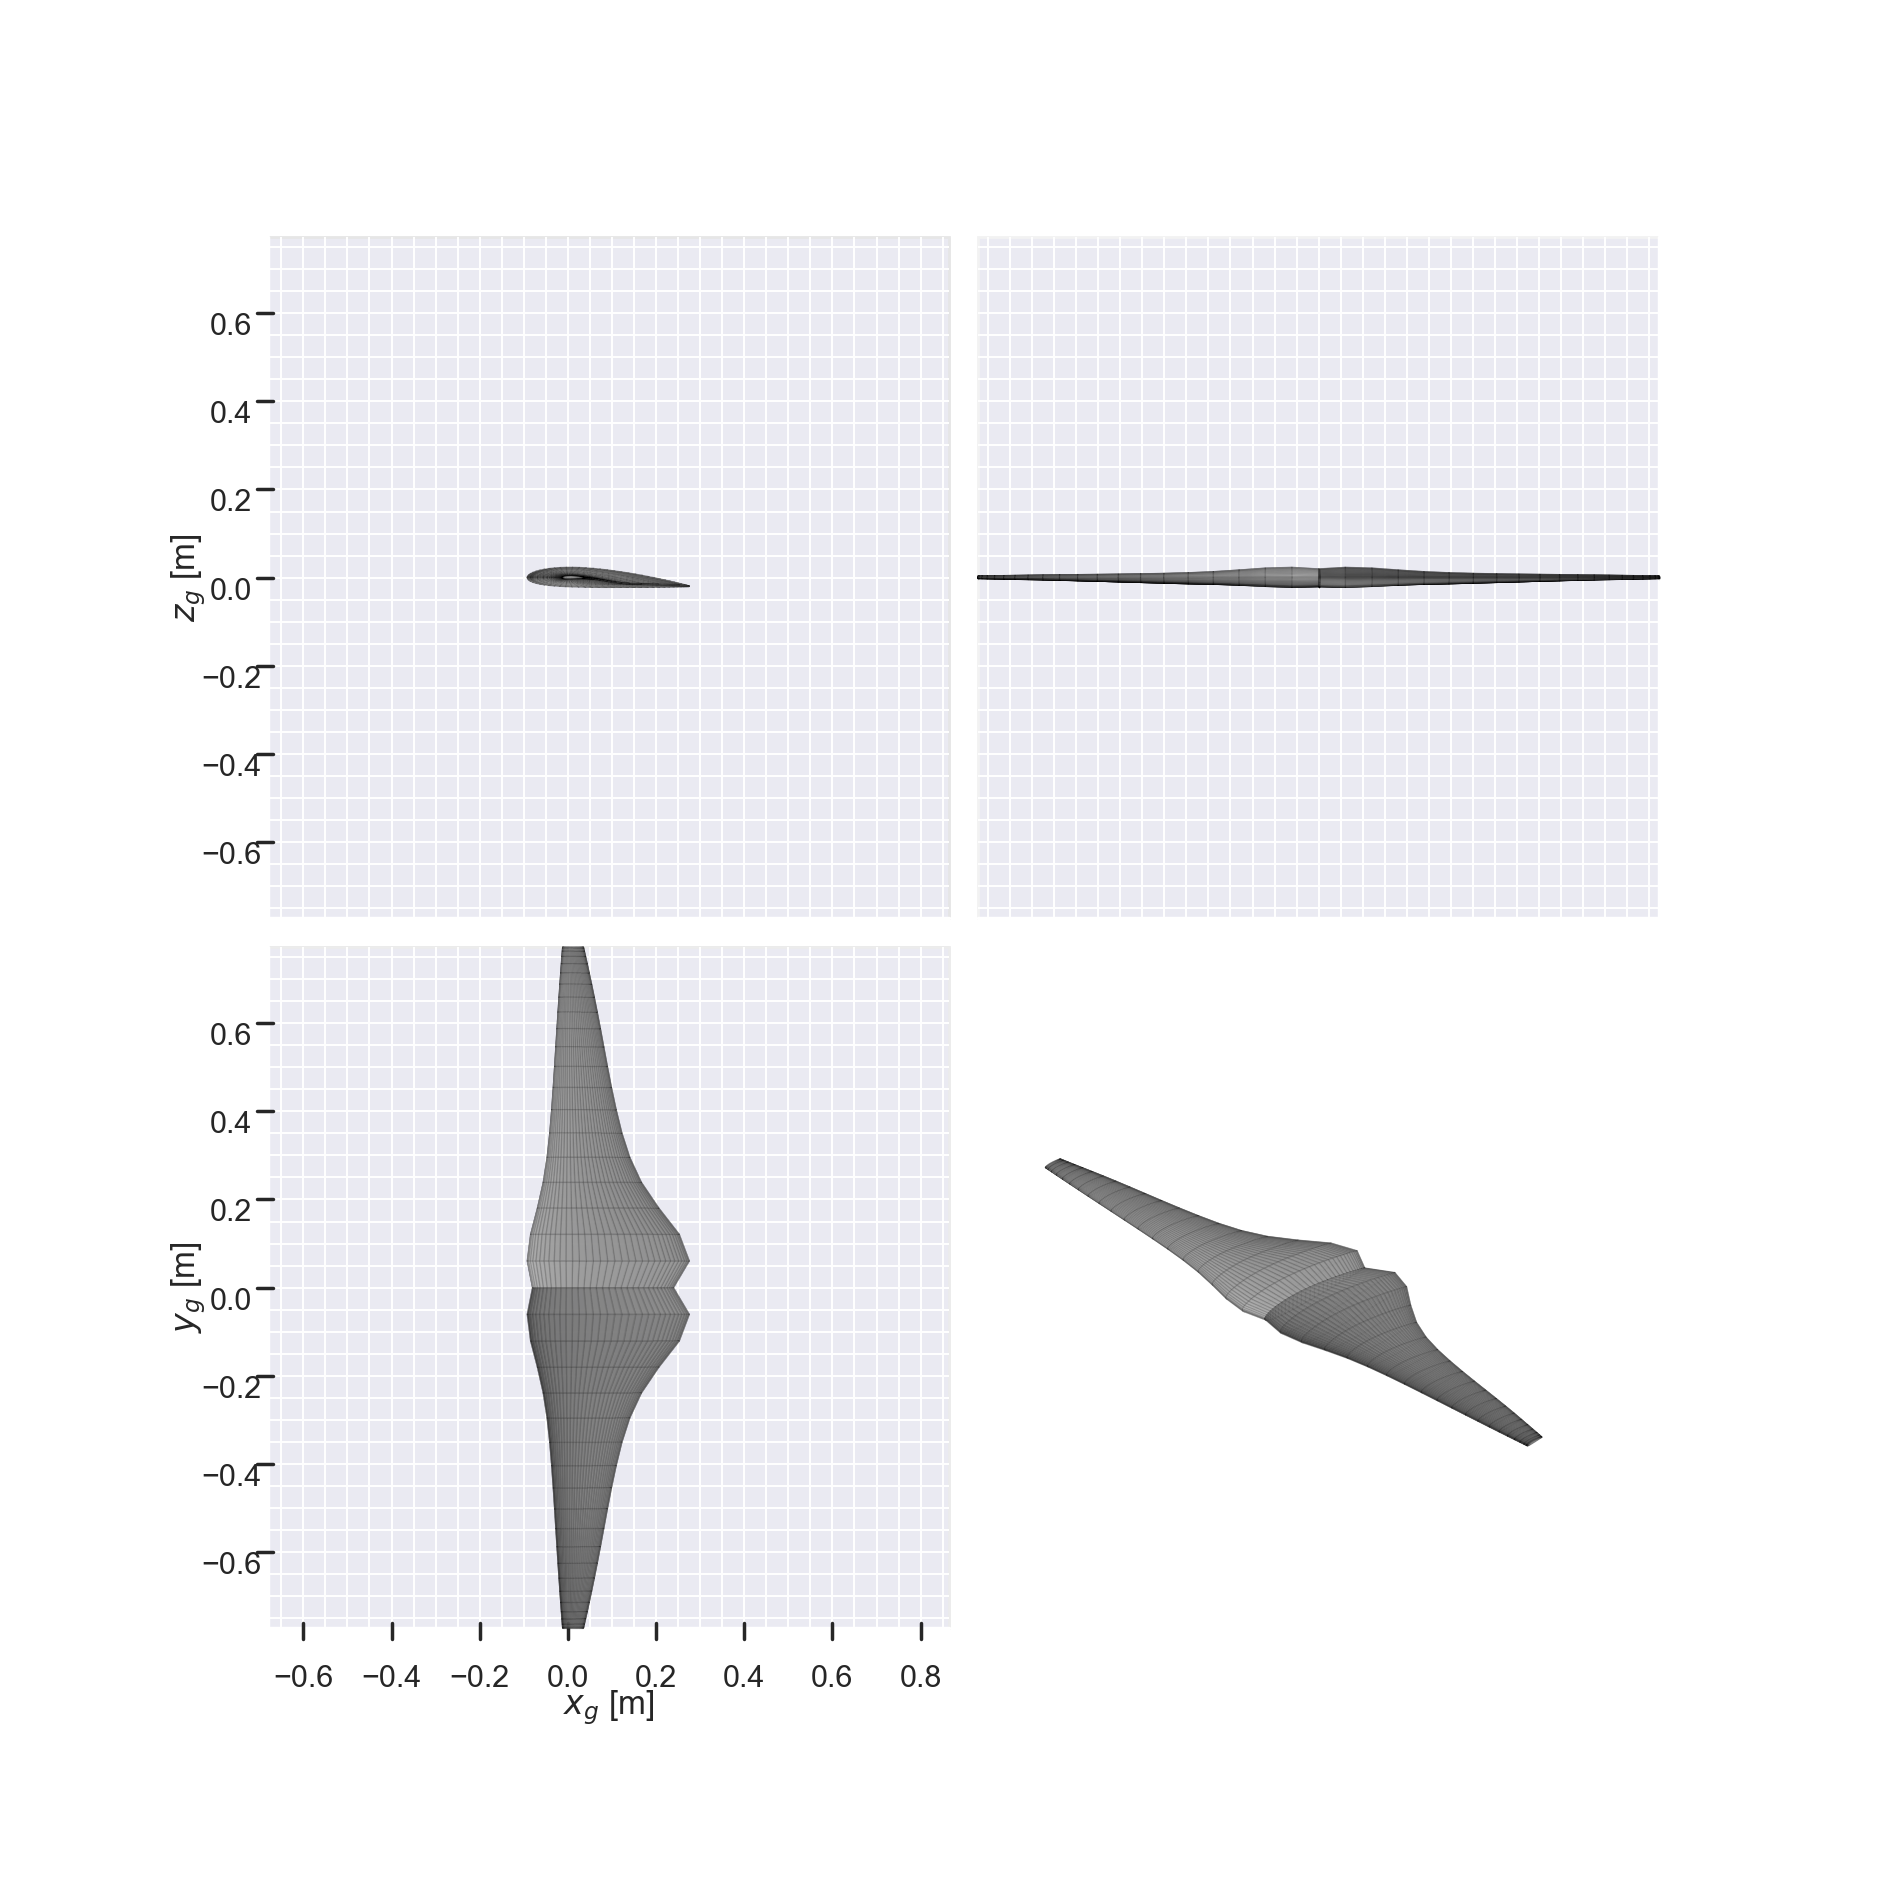

array([[<Axes3D: zlabel='$z_g$ [m]'>, <Axes3D: >],
       [<Axes3D: xlabel='$x_g$ [m]', ylabel='$y_g$ [m]'>, <Axes3D: >]],
      dtype=object)

In [6]:
# Optimize LLM with B-splined chord and twist, remove monotonic chord.

opti = asb.Opti()

N = 21
n_chord_cps = 7
n_twist_cps = 11
llm_spanwise_resolution = 1

S_ref_target = 0.2808812685
CL_target = 0.5
root_BM_target = 5  # N*m
wingspan = opti.variable(init_guess=0.7, lower_bound=0)
taper_ratio = 0.25
velocity = 20
alpha = 0

section_y = np.sinspace(0, wingspan, N, reverse_spacing=True)
section_eta = section_y / wingspan

def open_uniform_unit_knots(n_control_points, degree):
    n_internal_knots = n_control_points - degree - 1
    if n_internal_knots > 0:
        internal_knots = np.linspace(0, 1, n_internal_knots + 2)[1:-1]
    else:
        internal_knots = np.array([])
    return np.concatenate([
        np.zeros(degree + 1),
        internal_knots,
        np.ones(degree + 1),
    ])

chord_degree = 3
chord_knots = open_uniform_unit_knots(n_chord_cps, chord_degree)
chord_cp_y = np.linspace(section_y[0], section_y[-1], n_chord_cps)
initial_chord_cps = np.linspace(0.25, 0.25 * taper_ratio, n_chord_cps)
chord_cps = opti.variable(
    init_guess=initial_chord_cps,
    lower_bound=0.02,
    upper_bound=0.8,
)
chords = asb.bspline(section_eta, chord_cps, degree=chord_degree, knots=chord_knots)

# Keep the optimized chord control po:ygon generally tapered. Remove this if you want non-monotonic planforms.
#opti.subject_to(chord_cps[1:] <= chord_cps[:-1])

twist_degree = 3
twist_knots = open_uniform_unit_knots(n_twist_cps, twist_degree)
twist_cp_y = np.linspace(section_y[0], section_y[-1], n_twist_cps)
twist_cps = opti.variable(
    init_guess=np.zeros(n_twist_cps),
    lower_bound=-30,
    upper_bound=30,
)
twists = asb.bspline(section_eta, twist_cps, degree=twist_degree, knots=twist_knots)

airplane = asb.Airplane(
    name="Airplane",
    xyz_ref=[0, 0, 0],
    wings=[
        asb.Wing(
            name="Wing",
            symmetric=True,
            xsecs=[
                asb.WingXSec(
                    xyz_le=[-0.25 * chords[i], section_y[i], 0],
                    chord=chords[i],
                    twist=twists[i],
                    airfoil=asb.Airfoil("naca2412"),
                )
                for i in range(N)
            ],
        )
    ],
)

llm = asb.LiftingLine(
    airplane=airplane,
    op_point=asb.OperatingPoint(
        velocity=velocity,
        alpha=alpha,
    ),
    spanwise_resolution=llm_spanwise_resolution,
    align_trailing_vortices_with_wind=False,
)
llm_results = llm.run()

n_spanwise = (N - 1) * llm_spanwise_resolution
sorted_indices = np.concatenate(
    (
        np.arange(2 * n_spanwise - 1, n_spanwise - 1, -1),
        np.arange(n_spanwise),
    )
)

strip_y = llm.vortex_centers[:, 1]
sorted_y = strip_y[sorted_indices]
sorted_eta = np.abs(sorted_y) / wingspan
sorted_chords = asb.bspline(sorted_eta, chord_cps, degree=chord_degree, knots=chord_knots)

vortex_strengths = llm.vortex_strengths
sorted_vortex_strengths = vortex_strengths[sorted_indices]

q = llm.op_point.dynamic_pressure()
sectional_L = (2 * q / velocity) * sorted_vortex_strengths
cl = sectional_L / (q * sorted_chords)
clc = cl * sorted_chords
clc_cref = clc / airplane.c_ref

y_half = sorted_y[n_spanwise:]
L_half = sectional_L[n_spanwise:]

y_half = np.concatenate([np.array([0.0]), y_half, np.array([wingspan])], axis=0)
L_half = np.concatenate([np.array([L_half[0]]), L_half, np.array([0.0])], axis=0)

dy_half = np.diff(y_half)
L_avg = 0.5 * (L_half[:-1] + L_half[1:])
L_forces = L_avg * dy_half
y_forces = 0.5 * (y_half[:-1] + y_half[1:])
root_bending_moment = np.sum(L_forces * y_forces)

opti.subject_to([
    airplane.s_ref == S_ref_target,
    llm_results["CL"] == CL_target,
    root_bending_moment == root_BM_target,
])

opti.minimize(llm_results["D"])

sol = opti.solve(behavior_on_failure="return_last", max_iter=500)

sol_drag = sol(llm_results["D"])
sol_CD = sol(llm_results["CD"])
sol_CL = sol(llm_results["CL"])
sol_Cm = sol(llm_results["Cm"])
sol_root_bending_moment = sol(root_bending_moment)
sol_span = sol(wingspan)
sol_section_y = sol(section_y)
sol_chord_cp_y = sol(chord_cp_y)
sol_chord_cps = sol(chord_cps)
sol_chords = sol(chords)
sol_twist_cp_y = sol(twist_cp_y)
sol_twist_cps = sol(twist_cps)
sol_twists = sol(twists)
sol_sorted_y = sol(sorted_y)
sol_cl = sol(cl)
sol_clc_cref = sol(clc_cref)

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sol_section_y, sol_chords, "o-", label="section chord")
plt.plot(sol_chord_cp_y, sol_chord_cps, "s--", label="chord control points")
plt.xlabel("section y (m)")
plt.ylabel("chord (m)")
plt.title("Optimized B-splined Chord, LLM")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sol_section_y, sol_twists, "o-", label="section twist")
plt.plot(sol_twist_cp_y, sol_twist_cps, "s--", label="twist control points")
plt.xlabel("section y (m)")
plt.ylabel("twist (deg)")
plt.title("Optimized B-splined Twist, LLM")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sol_sorted_y, sol_clc_cref, color="green", label=r"$C_L \cdot c/c_{ref}$")
plt.plot(sol_sorted_y, sol_cl, color="orange", linestyle="--", label=r"$C_L$")
plt.xlabel("y (m)")
plt.legend()
plt.title("Cruise Lift and Lift Coefficient Distributions, LLM")
plt.grid(True, alpha=0.3)
plt.show()

llm_chord_y_plot, llm_chord_clc_plot = _area_normalized_curve(sol_sorted_y, sol_clc_cref)
comparison_semispan = np.max(np.abs(np.concatenate([vlm_y_plot, llm_y_plot, llm_chord_y_plot])))
comparison_y = np.linspace(-comparison_semispan, comparison_semispan, 400)
comparison_bell = (1 - (comparison_y / comparison_semispan) ** 2) ** 1.5
comparison_y_plot, comparison_bell_plot = _area_normalized_curve(comparison_y, comparison_bell)

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(vlm_y_plot, vlm_clc_plot, label="VLM twist-only")
plt.plot(llm_y_plot, llm_clc_plot, label="LLM twist-only")
plt.plot(llm_chord_y_plot, llm_chord_clc_plot, label="LLM chord+twist B-spline")
plt.plot(comparison_y_plot, comparison_bell_plot, "k--", label="Prandtl BSLD")
plt.xlabel("y (m)")
plt.ylabel(r"area-normalized $C_L \cdot c/c_{ref}$")
plt.title("Equal-Lift Loading Comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("drag [N]:", sol_drag)
print("CD:", sol_CD)
print("CL:", sol_CL)
print("Cm:", sol_Cm)
print("x_np [m]:", sol_x_np)
print("root bending moment [N*m]:", sol_root_bending_moment)
print("root bending moment target [N*m]:", root_BM_target)
print("span [m]:", sol_span)
print("section_y:", sol_section_y)
print("chord control point y:", sol_chord_cp_y)
print("chord control points:", sol_chord_cps)
print("section chords:", sol_chords)
print("twist control point y:", sol_twist_cp_y)
print("twist control points:", sol_twist_cps)
print("section twists:", sol_twists)
print("sorted_y:", sol_sorted_y)
print("cl:", sol_cl)
print("clc_cref:", sol_clc_cref)

sol(airplane).draw_three_view()

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:       76
Number of nonzeros in inequality constraint Jacobian.:       49
Number of nonzeros in Lagrangian Hessian.............:      190

Total number of variables............................:       19
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        4
Total number of inequality constraints...............:       43
        inequality constraints with only lower bounds:       19
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       24

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  5.9680884e-01 2.99e+01 4.97e-02   0.0 0.00e+00    -  0.00e+00 0.00e+00 

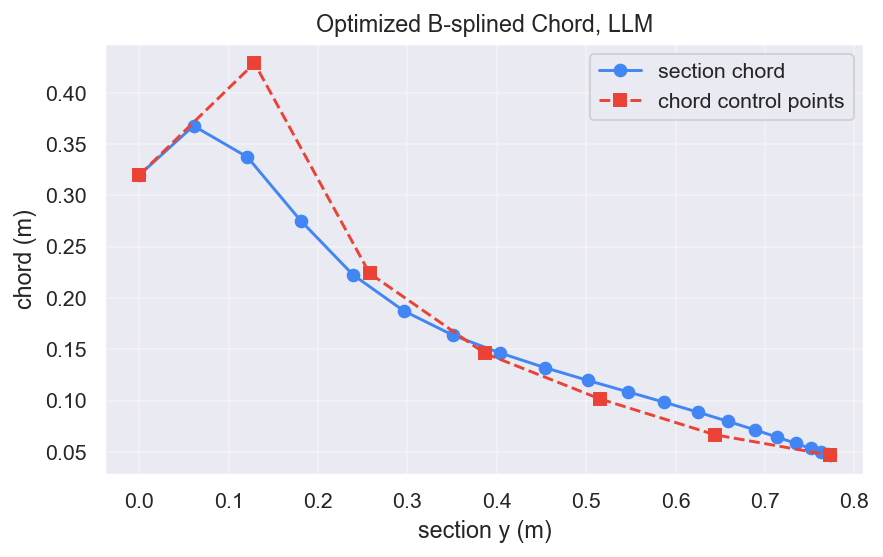

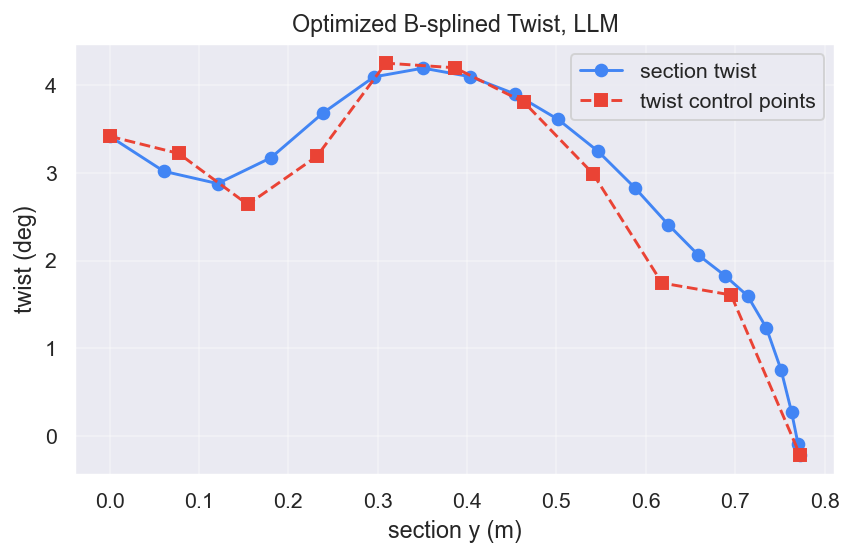

RuntimeError: Error in Opti::value [OptiNode] at .../casadi/core/optistack.cpp:233:
.../casadi/core/optistack_internal.cpp:653: Unknown: Opti decision variable 'opti3_x_1' of shape 1x1, belonging to a different instance of Opti.

<Figure size 980x560 with 0 Axes>

In [9]:
# Optimize LLM with B-splined chord and twist. Cruise, manuever, stall.

def LiftingLineCase(airplane, velocity, alpha, llm_spanwise_resolution, wingspan):
    llm = asb.LiftingLine(
        airplane=airplane,
        op_point=asb.OperatingPoint(
            velocity=velocity,
            alpha=alpha,
        ),
        spanwise_resolution=llm_spanwise_resolution,
        align_trailing_vortices_with_wind=False,
    )
    llm_results = llm.run()
    
    n_spanwise = (N - 1) * llm_spanwise_resolution
    sorted_indices = np.concatenate(
        (
            np.arange(2 * n_spanwise - 1, n_spanwise - 1, -1),
            np.arange(n_spanwise),
        )
    )
    
    strip_y = llm.vortex_centers[:, 1]
    sorted_y = strip_y[sorted_indices]
    sorted_eta = np.abs(sorted_y) / wingspan
    sorted_chords = asb.bspline(sorted_eta, chord_cps, degree=chord_degree, knots=chord_knots)
    
    vortex_strengths = llm.vortex_strengths
    sorted_vortex_strengths = vortex_strengths[sorted_indices]
    
    q = llm.op_point.dynamic_pressure()
    sectional_L = (2 * q / velocity) * sorted_vortex_strengths
    cl = sectional_L / (q * sorted_chords)
    clc = cl * sorted_chords
    clc_cref = clc / airplane.c_ref
    
    y_half = sorted_y[n_spanwise:]
    L_half = sectional_L[n_spanwise:]
    
    y_half = np.concatenate([np.array([0.0]), y_half, np.array([wingspan])], axis=0)
    L_half = np.concatenate([np.array([L_half[0]]), L_half, np.array([0.0])], axis=0)
    
    dy_half = np.diff(y_half)
    L_avg = 0.5 * (L_half[:-1] + L_half[1:])
    L_forces = L_avg * dy_half
    y_forces = 0.5 * (y_half[:-1] + y_half[1:])
    root_bending_moment = np.sum(L_forces * y_forces)

    return llm_results, root_bending_moment, cl, clc_cref

# Setup
opti = asb.Opti()

# Paneling
N = 21
n_chord_cps = 7
n_twist_cps = 11
llm_spanwise_resolution = 1

# Constants
rho = 1.225
alpha = 0
W = 36  # N
BM_turn = 5  # N*m
taper_ratio_initial = 0.25

# Velocities
v_stall = 14  # m/s
v_turn = 1.2 * v_stall  # m/s
v_cruise = 1.2 * v_stall + 3  # m/s

# Design variables
wingspan = opti.variable(init_guess=0.7, lower_bound=0)
section_y = np.sinspace(0, wingspan, N, reverse_spacing=True)
section_eta = section_y / wingspan

# Knots function
def open_uniform_unit_knots(n_control_points, degree):
    n_internal_knots = n_control_points - degree - 1
    if n_internal_knots > 0:
        internal_knots = np.linspace(0, 1, n_internal_knots + 2)[1:-1]
    else:
        internal_knots = np.array([])
    return np.concatenate([
        np.zeros(degree + 1),
        internal_knots,
        np.ones(degree + 1),
    ])

# Chord
chord_degree = 3
chord_knots = open_uniform_unit_knots(n_chord_cps, chord_degree)
chord_cp_y = np.linspace(section_y[0], section_y[-1], n_chord_cps)
initial_chord_cps = np.linspace(0.25, 0.25 * taper_ratio, n_chord_cps)
chord_cps = opti.variable(
    init_guess=initial_chord_cps,
    lower_bound=0.02,
    upper_bound=0.8,
)
chords = asb.bspline(section_eta, chord_cps, degree=chord_degree, knots=chord_knots)

# Keep the optimized chord control polygon generally tapered. Remove this if you want non-monotonic planforms.
opti.subject_to(chord_cps[1:] <= chord_cps[:-1])

# Twist
twist_degree = 3
twist_knots = open_uniform_unit_knots(n_twist_cps, twist_degree)
twist_cp_y = np.linspace(section_y[0], section_y[-1], n_twist_cps)
twist_cps = opti.variable(
    init_guess=np.zeros(n_twist_cps),
    lower_bound=-30,
    upper_bound=30,
)
twists = asb.bspline(section_eta, twist_cps, degree=twist_degree, knots=twist_knots)

# Airplane
airplane = asb.Airplane(
    name="Airplane",
    xyz_ref=[0, 0, 0],
    wings=[
        asb.Wing(
            name="Wing",
            symmetric=True,
            xsecs=[
                asb.WingXSec(
                    xyz_le=[-0.25 * chords[i], section_y[i], 0],
                    chord=chords[i],
                    twist=twists[i],
                    airfoil=asb.Airfoil("naca2412"),
                )
                for i in range(N)
            ],
        )
    ],
)

# LLM Cases
llm_results_stall, root_BM_stall, cl_stall, clc_cref_stall = LiftingLineCase(airplane, v_stall, alpha)
llm_results_turn, root_BM_turn, cl_turn, clc_cref_turn = LiftingLineCase(airplane, v_turn, alpha)
llm_results_cruise, root_BM_cruise, cl_cruise, clc_cref_cruise = LiftingLineCase(airplane, v_cruise, alpha)

# Constraints
opti.subject_to([
    llm_results_stall["L"] == W,
    llm_results_turn["L"] == W,
    llm_results_cruise["L"] == W,
    root_BM_turn == root_BM_target,
])

opti.minimize(llm_results_cruise["D"])

sol = opti.solve(behavior_on_failure="return_last", max_iter=500)

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sol_section_y, sol_chords, "o-", label="section chord")
plt.plot(sol_chord_cp_y, sol_chord_cps, "s--", label="chord control points")
plt.xlabel("section y (m)")
plt.ylabel("chord (m)")
plt.title("Optimized B-splined Chord, LLM")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sol_section_y, sol_twists, "o-", label="section twist")
plt.plot(sol_twist_cp_y, sol_twist_cps, "s--", label="twist control points")
plt.xlabel("section y (m)")
plt.ylabel("twist (deg)")
plt.title("Optimized B-splined Twist, LLM")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sol(sorted_y), sol(clc_cref_stall), color="green", label=r"$C_L \cdot c/c_{ref}$")
plt.plot(sol(sorted_y), sol(cl_stall), color="orange", linestyle="--", label=r"$C_L$")
plt.xlabel("y (m)")
plt.legend()
plt.title("Stall Lift and Lift Coefficient Distributions")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sol(sorted_y), sol(clc_cref_turn), color="green", label=r"$C_L \cdot c/c_{ref}$")
plt.plot(sol(sorted_y), sol(cl_turn), color="orange", linestyle="--", label=r"$C_L$")
plt.xlabel("y (m)")
plt.legend()
plt.title("Turn Lift and Lift Coefficient Distributions")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sol(sorted_y), sol(clc_cref_cruise), color="green", label=r"$C_L \cdot c/c_{ref}$")
plt.plot(sol(sorted_y), sol(cl_cruise), color="orange", linestyle="--", label=r"$C_L$")
plt.xlabel("y (m)")
plt.legend()
plt.title("Cruise Lift and Lift Coefficient Distributions")
plt.grid(True, alpha=0.3)
plt.show()

sol(airplane).draw_three_view()

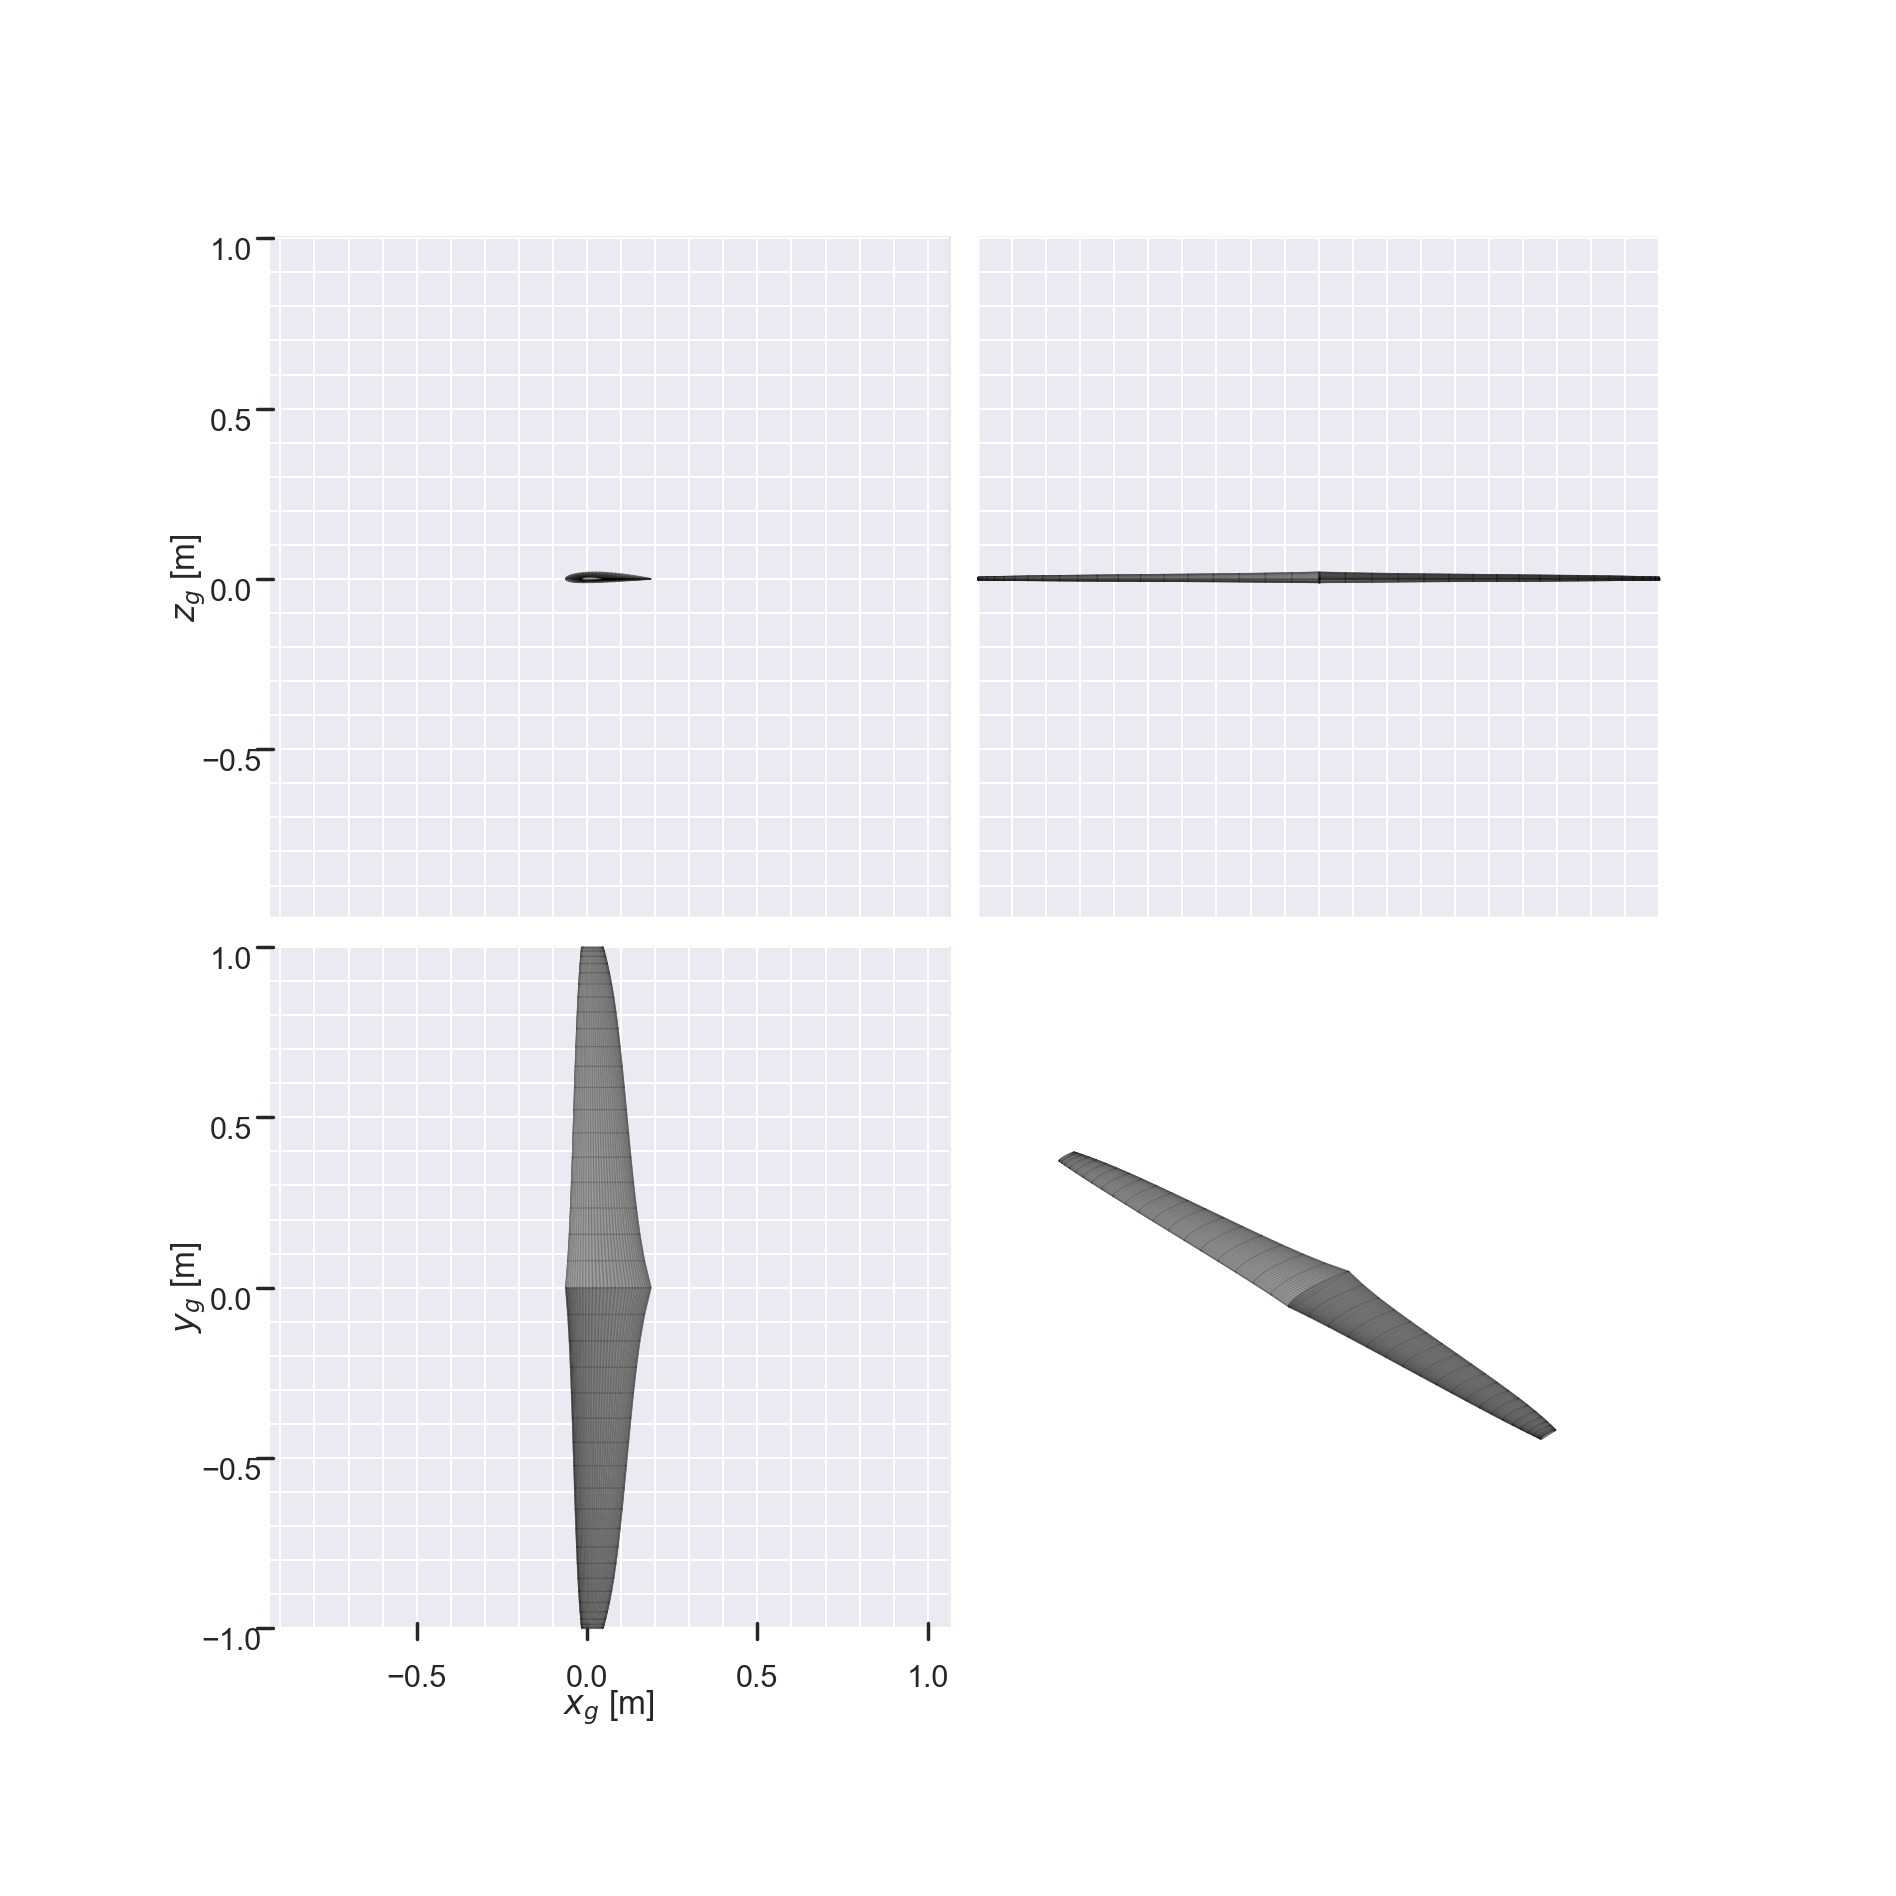

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 2 has 1 dimension(s)

In [9]:
def LiftingLineCase(airplane, velocity, alpha, llm_spanwise_resolution, wingspan):
    llm = asb.LiftingLine(
        airplane=airplane,
        op_point=asb.OperatingPoint(
            velocity=velocity,
            alpha=alpha,
        ),
        spanwise_resolution=llm_spanwise_resolution,
        align_trailing_vortices_with_wind=False,
    )
    llm_results = llm.run()
    
    n_spanwise = (N - 1) * llm_spanwise_resolution
    sorted_indices = np.concatenate(
        (
            np.arange(2 * n_spanwise - 1, n_spanwise - 1, -1),
            np.arange(n_spanwise),
        )
    )
    
    strip_y = llm.vortex_centers[:, 1]
    sorted_y = strip_y[sorted_indices]
    sorted_eta = np.abs(sorted_y) / wingspan
    sorted_chords = asb.bspline(sorted_eta, chord_cps, degree=chord_degree, knots=chord_knots)
    
    vortex_strengths = llm.vortex_strengths
    sorted_vortex_strengths = vortex_strengths[sorted_indices]
    
    q = llm.op_point.dynamic_pressure()
    sectional_L = (2 * q / velocity) * sorted_vortex_strengths
    cl = sectional_L / (q * sorted_chords)
    clc = cl * sorted_chords
    clc_cref = clc / airplane.c_ref
    
    y_half = sorted_y[n_spanwise:]
    L_half = sectional_L[n_spanwise:]
    
    y_half = np.concatenate([np.array([0.0]), y_half, np.array([wingspan])], axis=0)
    L_half = np.concatenate([np.array([L_half[0]]), L_half, np.array([0.0])], axis=0)
    
    dy_half = np.diff(y_half)
    L_avg = 0.5 * (L_half[:-1] + L_half[1:])
    L_forces = L_avg * dy_half
    y_forces = 0.5 * (y_half[:-1] + y_half[1:])
    root_bending_moment = np.sum(L_forces * y_forces)

    return llm_results, root_bending_moment, cl, clc_cref

# Paneling
N = 21
n_chord_cps = 7
n_twist_cps = 11
llm_spanwise_resolution = 1

# Constants
rho = 1.225
alpha = 0
W = 36  # N
BM_turn = 5  # N*m
taper_ratio_initial = 0.25

# Velocities
v_stall = 14  # m/s
v_turn = 1.2 * v_stall  # m/s
v_cruise = 1.2 * v_stall + 3  # m/s

# Design variables
wingspan = 1
section_y = np.sinspace(0, wingspan, N, reverse_spacing=True)
section_eta = section_y / wingspan

# Knots function
def open_uniform_unit_knots(n_control_points, degree):
    n_internal_knots = n_control_points - degree - 1
    if n_internal_knots > 0:
        internal_knots = np.linspace(0, 1, n_internal_knots + 2)[1:-1]
    else:
        internal_knots = np.array([])
    return np.concatenate([
        np.zeros(degree + 1),
        internal_knots,
        np.ones(degree + 1),
    ])

# Chord
chord_degree = 3
chord_knots = open_uniform_unit_knots(n_chord_cps, chord_degree)
chord_cp_y = np.linspace(section_y[0], section_y[-1], n_chord_cps)
initial_chord_cps = np.linspace(0.25, 0.25 * taper_ratio_initial, n_chord_cps)
chord_cps = initial_chord_cps
chords = asb.bspline(section_eta, chord_cps, degree=chord_degree, knots=chord_knots)

# Twist
twist_degree = 3
twist_knots = open_uniform_unit_knots(n_twist_cps, twist_degree)
twist_cp_y = np.linspace(section_y[0], section_y[-1], n_twist_cps)
twist_cps = np.zeros(n_twist_cps)
twists = asb.bspline(section_eta, twist_cps, degree=twist_degree, knots=twist_knots)

# Airplane
airplane = asb.Airplane(
    name="Airplane",
    xyz_ref=[0, 0, 0],
    wings=[
        asb.Wing(
            name="Wing",
            symmetric=True,
            xsecs=[
                asb.WingXSec(
                    xyz_le=[-0.25 * chords[i], section_y[i], 0],
                    chord=chords[i],
                    twist=twists[i],
                    airfoil=asb.Airfoil("naca2412"),
                )
                for i in range(N)
            ],
        )
    ],
)

airplane.draw_three_view()

llm_results_stall, root_BM_stall, cl_stall, clc_cref_stall = LiftingLineCase(airplane, v_stall, alpha, llm_spanwise_resolution, wingspan)

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(section_y, chords, "o-", label="section chord")
plt.plot(chord_cp_y, chord_cps, "s--", label="chord control points")
plt.xlabel("section y (m)")
plt.ylabel("chord (m)")
plt.title("Optimized B-splined Chord, LLM")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(section_y, twists, "o-", label="section twist")
plt.plot(twist_cp_y, twist_cps, "s--", label="twist control points")
plt.xlabel("section y (m)")
plt.ylabel("twist (deg)")
plt.title("Optimized B-splined Twist, LLM")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(sorted_y, clc_cref_stall, color="green", label=r"$C_L \cdot c/c_{ref}$")
plt.plot(sorted_y, cl_stall, color="orange", linestyle="--", label=r"$C_L$")
plt.xlabel("y (m)")
plt.legend()
plt.title("Stall Lift and Lift Coefficient Distributions")
plt.grid(True, alpha=0.3)
plt.show()